# Notebook unico del team - pulizia dati + 3 temi analitici

Questo notebook unisce il lavoro fatto separatamente dal team in questi notebook:

- `EDA_unito_V0.3.ipynb` (Lorenzo) - caricamento, pulizia e feature engineering condivisi
- `ecosistema_giada.ipynb` (Giada) - tema "analisi ecosistema"
- `EDA_decadimento_specie.ipynb` (Lorenzo) - tema "decadimento delle specie prima del K-Pg"
- `evoluzione_Danilo.ipynb` (Danilo) - tema "evoluzione/sviluppo della specie verso la linea aviaria"

**Perche' questo notebook esiste**: finora la pipeline ETL (`etl/pipeline.py`, `etl/pipeline_postgres.py`) leggeva
`data/processed/dinos_clean.csv` / `plants_clean.csv`, prodotti da un notebook di pulizia piu' vecchio
(`cleaning_Danilo.ipynb`), diverso dalla pulizia fatta qui. Da questo notebook in poi si parte invece dalla
pulizia condivisa in `EDA_unito` (Parte A), cosi' tutti i temi lavorano sullo stesso dataset di base
(`df_fossili_clean`) invece che su CSV pre-elaborati diversi tra loro.

## Struttura

- **Parte A** - Import, caricamento dataset grezzi, pulizia e feature engineering condivisi (base: EDA_unito)
- **Parte B** - Tema Ecosistema (Giada)
- **Parte C** - Tema Decadimento delle specie (Lorenzo)
- **Parte D** - Tema Evoluzione / linea aviaria (Danilo)
- **Parte E** - Conclusioni generali

Le tre parti tematiche (B, C, D) condividono lo stesso dataset di base `df_fossili_clean`, e usano tutte lo
stesso flag booleano `possibile_aviano_residuo` per gestire gli ordini di uccelli mesozoici "arcaici" rimasti
classificati come `Reptilia` invece che come `Aves`: il tema ecosistema li esclude (restando sui soli dinosauri
"classici"), i temi decadimento ed evoluzione li trattano diversamente a seconda della domanda (vedi le
rispettive sezioni).

# PARTE A - Pulizia dati e feature engineering condivisi (base: EDA_unito, Lorenzo)

## 1. Import librerie

### 1.1 Setup librerie

#### 1.1.1 Import librerie

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
rosso = 'firebrick'
verde = 'forestgreen' 

## 2. Load dataset

### 2.1 Caricamento dataset

#### 2.1.1 Caricamento dataset

In [2]:
df_dino = pd.read_csv('../data/raw/dinos.csv')
df_plants = pd.read_csv('../data/raw/plants.csv')

#### 2.1.2 Dimensioni dei dataset

In [3]:
print('Dinosauri:', df_dino.shape)
print('Piante:', df_plants.shape)

Dinosauri: (37790, 38)
Piante: (57394, 38)


#### 2.1.3 Anteprima dinosauri

In [4]:
df_dino.head()

,occurrence_no,record_type,reid_no,flags,collection_no,identified_name,identified_rank,identified_no,difference,accepted_name,...,geogcomments,cx_int_no,formation,geological_group,member,phylum,class,order,family,genus
0,41524,occ,NaN,NaN,3257,Aves indet.,class,NaN,NaN,Aves,...,at Dummer's Copse between Allington Lane and Q...,37.0,NaN,Bracklesham,NaN,Chordata,Aves,NaN,NaN,NaN
1,41580,occ,NaN,NaN,3256,Aves indet.,class,NaN,NaN,Aves,...,"at Dummer's Copse, between Allington Lane and ...",37.0,NaN,Bracklesham,NaN,Chordata,Aves,NaN,NaN,NaN
2,130209,occ,NaN,NaN,10755,Chaoyangosaurus liaosiensis n. gen. n. sp.,species,65704.0,NaN,Chaoyangsaurus youngi,...,"Chaoyang area of Liaoning Province, NE China",2.0,Tuchengzi,NaN,NaN,Chordata,Ornithischia,NO_ORDER_SPECIFIED,Chaoyangsauridae,Chaoyangsaurus
3,130294,occ,NaN,NaN,10764,Protarchaeopteryx robusta n. gen. n. sp.,species,NaN,NaN,Protarchaeopteryx robusta,...,Sihetun area near Beipiao city,40.0,Yixian,Jehol,Jianshangou,Chordata,Reptilia,NO_ORDER_SPECIFIED,NO_FAMILY_SPECIFIED,Protarchaeopteryx
4,130295,occ,NaN,NaN,10764,Caudipteryx zoui n. gen. n. sp.,species,NaN,NaN,Caudipteryx zoui,...,Sihetun area near Beipiao city,40.0,Yixian,Jehol,Jianshangou,Chordata,Reptilia,NO_ORDER_SPECIFIED,NO_FAMILY_SPECIFIED,Caudipteryx


#### 2.1.4 Anteprima piante

In [5]:
df_plants.head()

,occurrence_no,record_type,reid_no,flags,collection_no,identified_name,identified_rank,identified_no,difference,accepted_name,...,geogcomments,cx_int_no,formation,geological_group,member,phylum,class,order,family,genus
0,31284,occ,NaN,NaN,2260,Algae indet.,class,NaN,NaN,Algae,...,This is a collection based on a composite of t...,121.0,Alikper,NaN,NaN,NO_PHYLUM_SPECIFIED,Algae,NaN,NaN,NaN
1,45807,occ,NaN,NaN,3640,? Caryophyllidae indet.,subclass,NaN,NaN,Caryophyllidae,...,Pitt Island,39.0,Kahuitara Tuff,NaN,NaN,Angiospermae,Dicotyledoneae,NaN,NaN,NaN
2,77082,occ,NaN,NaN,1573,Plantae indet.,kingdom,NaN,NaN,Plantae,...,cliff below Sandsfoot Castle,126.0,Sandsfoot Grit,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,77169,occ,NaN,NaN,1567,Plantae indet.,kingdom,NaN,NaN,Plantae,...,cliff below Sandsfoot Castle,126.0,Sandsfoot Grit,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,82793,occ,NaN,NaN,1555,Diplopora versipora,genus,NaN,species not entered,Diplopora,...,coastal cliff between Black Head and Shortlake,126.0,Trigonia clavellata,NaN,NaN,Chlorophyta,Chlorophyceae,Dasycladales,Diploporaceae,Diplopora


## 3. EDA dinosauri

### 3.1 Anteprima e struttura

#### 3.1.1 Prime righe dinosauri

In [6]:
df_dino.head()

,occurrence_no,record_type,reid_no,flags,collection_no,identified_name,identified_rank,identified_no,difference,accepted_name,...,geogcomments,cx_int_no,formation,geological_group,member,phylum,class,order,family,genus
0,41524,occ,NaN,NaN,3257,Aves indet.,class,NaN,NaN,Aves,...,at Dummer's Copse between Allington Lane and Q...,37.0,NaN,Bracklesham,NaN,Chordata,Aves,NaN,NaN,NaN
1,41580,occ,NaN,NaN,3256,Aves indet.,class,NaN,NaN,Aves,...,"at Dummer's Copse, between Allington Lane and ...",37.0,NaN,Bracklesham,NaN,Chordata,Aves,NaN,NaN,NaN
2,130209,occ,NaN,NaN,10755,Chaoyangosaurus liaosiensis n. gen. n. sp.,species,65704.0,NaN,Chaoyangsaurus youngi,...,"Chaoyang area of Liaoning Province, NE China",2.0,Tuchengzi,NaN,NaN,Chordata,Ornithischia,NO_ORDER_SPECIFIED,Chaoyangsauridae,Chaoyangsaurus
3,130294,occ,NaN,NaN,10764,Protarchaeopteryx robusta n. gen. n. sp.,species,NaN,NaN,Protarchaeopteryx robusta,...,Sihetun area near Beipiao city,40.0,Yixian,Jehol,Jianshangou,Chordata,Reptilia,NO_ORDER_SPECIFIED,NO_FAMILY_SPECIFIED,Protarchaeopteryx
4,130295,occ,NaN,NaN,10764,Caudipteryx zoui n. gen. n. sp.,species,NaN,NaN,Caudipteryx zoui,...,Sihetun area near Beipiao city,40.0,Yixian,Jehol,Jianshangou,Chordata,Reptilia,NO_ORDER_SPECIFIED,NO_FAMILY_SPECIFIED,Caudipteryx


#### 3.1.2 Info colonne dinosauri

In [7]:
df_dino.info()

<class 'pandas.DataFrame'>
RangeIndex: 37790 entries, 0 to 37789
Data columns (total 38 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   occurrence_no     37790 non-null  int64  
 1   record_type       37790 non-null  str    
 2   reid_no           4154 non-null   float64
 3   flags             3417 non-null   str    
 4   collection_no     37790 non-null  int64  
 5   identified_name   37790 non-null  str    
 6   identified_rank   37790 non-null  str    
 7   identified_no     12703 non-null  float64
 8   difference        3889 non-null   str    
 9   accepted_name     37790 non-null  str    
 10  accepted_attr     37748 non-null  str    
 11  accepted_rank     37790 non-null  str    
 12  accepted_no       37790 non-null  int64  
 13  early_interval    37790 non-null  str    
 14  late_interval     8675 non-null   str    
 15  max_ma            37790 non-null  float64
 16  min_ma            37790 non-null  float64
 17  refe

### 3.2 Valori mancanti

#### 3.2.1 Conteggio valori nulli

In [8]:
df_dino.isnull().sum()

occurrence_no           0
record_type             0
reid_no             33636
flags               34373
collection_no           0
identified_name         0
identified_rank         0
identified_no       25087
difference          33901
accepted_name           0
accepted_attr          42
accepted_rank           0
accepted_no             0
early_interval          0
late_interval       29115
max_ma                  0
min_ma                  0
reference_no            0
lng                     0
lat                     0
cc                     17
state                6320
county              19061
latlng_basis         1611
latlng_precision        0
altitude_value      29120
altitude_unit       29211
geogscale            6627
geogcomments         7883
cx_int_no              62
formation           14347
geological_group    27438
member              30582
phylum                  0
class                   0
order                7379
family               8723
genus               14232
dtype: int64

#### 3.2.2 Percentuale valori nulli

In [9]:
(df_dino.isnull().sum() / len(df_dino) * 100).round(2)

occurrence_no        0.00
record_type          0.00
reid_no             89.01
flags               90.96
collection_no        0.00
identified_name      0.00
identified_rank      0.00
identified_no       66.39
difference          89.71
accepted_name        0.00
accepted_attr        0.11
accepted_rank        0.00
accepted_no          0.00
early_interval       0.00
late_interval       77.04
max_ma               0.00
min_ma               0.00
reference_no         0.00
lng                  0.00
lat                  0.00
cc                   0.04
state               16.72
county              50.44
latlng_basis         4.26
latlng_precision     0.00
altitude_value      77.06
altitude_unit       77.30
geogscale           17.54
geogcomments        20.86
cx_int_no            0.16
formation           37.97
geological_group    72.61
member              80.93
phylum               0.00
class                0.00
order               19.53
family              23.08
genus               37.66
dtype: float

#### 3.2.3 Colonne con piu valori nulli

In [10]:
nulli_dino = (df_dino.isnull().sum() / len(df_dino) * 100).sort_values(ascending=False).head(15)
nulli_dino

flags               90.957925
difference          89.708918
reid_no             89.007674
member              80.926171
altitude_unit       77.298227
altitude_value      77.057423
late_interval       77.044192
geological_group    72.606510
identified_no       66.385287
county              50.439270
formation           37.965070
genus               37.660757
family              23.082826
geogcomments        20.860016
order               19.526330
dtype: float64

#### 3.2.4 Grafico valori mancanti

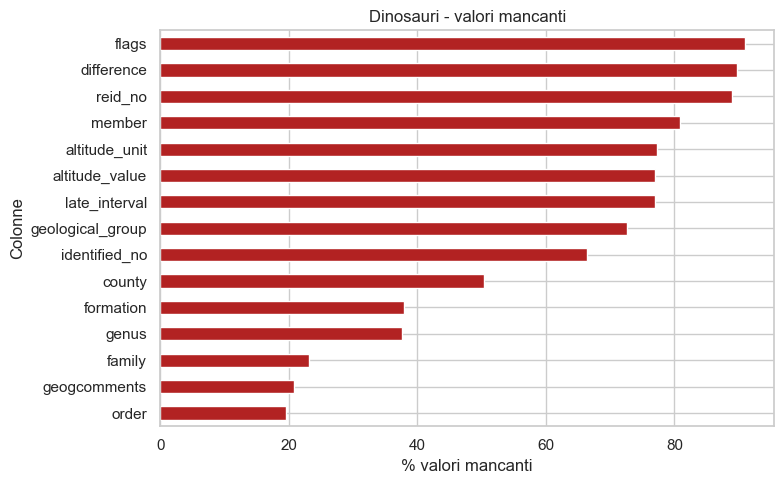

In [11]:
nulli_dino.sort_values().plot(kind='barh', color=rosso, figsize=(8, 5))
plt.title('Dinosauri - valori mancanti')
plt.xlabel('% valori mancanti')
plt.ylabel('Colonne')
plt.tight_layout()
plt.show()

### 3.3 Duplicati

#### 3.3.1 Controllo duplicati

In [12]:
df_dino.duplicated().sum()

np.int64(0)

### 3.4 Conteggi per categoria

#### 3.4.1 Conteggio classi

In [13]:
df_dino['class'].value_counts(dropna=False).head(15)

class
Aves            15173
Reptilia        11164
Ornithischia     7058
Saurischia       4395
Name: count, dtype: int64

#### 3.4.2 Conteggio ordini

In [14]:
df_dino['order'].value_counts(dropna=False).head(15)

order
NO_ORDER_SPECIFIED    14825
NaN                    7379
Passeriformes          2352
Charadriiformes        1949
Anseriformes           1821
Gruiformes             1040
Procellariiformes       959
Galliformes             934
Accipitriformes         782
Columbiformes           744
Suliformes              741
Strigiformes            604
Pelecaniformes          424
Sphenisciformes         317
Falconiformes           299
Name: count, dtype: int64

#### 3.4.3 Conteggio famiglie

In [15]:
df_dino['family'].value_counts(dropna=False).head(15)

family
NaN                    8723
NO_FAMILY_SPECIFIED    3043
Anatidae               1731
Hadrosauridae          1623
Dromaeosauridae        1015
Grallatoridae           835
Accipitridae            760
Procellariidae          756
Ceratopsidae            747
Columbidae              744
Rallidae                727
Phasianidae             662
Alcidae                 545
Tyrannosauridae         510
Scolopacidae            507
Name: count, dtype: int64

#### 3.4.4 Conteggio generi

In [16]:
df_dino['genus'].value_counts(dropna=False).head(15)

genus
NaN                14232
Grallator            431
Anas                 336
Eubrontes            304
Phalacrocorax        278
Corvus               270
Puffinus             244
Richardoestesia      238
Falco                198
Megaloolithus        183
Turdus               177
Pterodroma           174
Buteo                170
Triceratops          166
Anomoepus            158
Name: count, dtype: int64

#### 3.4.5 Conteggio paesi

In [17]:
df_dino['cc'].value_counts(dropna=False).head(15)

cc
US    11377
CA     2225
ES     2224
CN     1975
NZ     1268
AR     1215
UK     1184
FR     1037
MN      980
AU      830
IT      681
MX      584
BR      582
PT      533
MG      419
Name: count, dtype: int64

#### 3.4.6 Conteggio intervalli geologici

In [18]:
df_dino['early_interval'].value_counts(dropna=False).head(15)

early_interval
Holocene               5409
Late Pleistocene       4772
Late Campanian         2619
Late Maastrichtian     1511
Maastrichtian          1387
Kimmeridgian           1109
Middle Campanian        955
Aptian                  955
Hettangian              800
Early Maastrichtian     696
Campanian               637
Lancian                 589
Late Kimmeridgian       558
Middle Pleistocene      541
Norian                  522
Name: count, dtype: int64

### 3.5 Statistiche descrittive

#### 3.5.1 Statistiche descrittive

In [19]:
df_dino.describe()

,occurrence_no,reid_no,collection_no,identified_no,accepted_no,max_ma,min_ma,reference_no,lng,lat,altitude_value,cx_int_no
count,3.779000e+04,4154.000000,37790.000000,12703.000000,37790.000000,37790.000000,37790.000000,37790.000000,37790.000000,37790.000000,8670.000000,37728.000000
mean,1.111161e+06,30509.549350,122537.062159,210102.997953,136205.014051,71.008821,64.523279,49143.774358,-19.988668,24.989404,991.356055,189.010549
std,4.505221e+05,8840.766784,73859.233773,136267.822972,132610.253551,65.819122,61.616788,26523.281573,92.791387,29.819606,1148.334106,294.044695
min,4.152400e+04,10063.000000,3256.000000,36610.000000,36616.000000,0.011700,0.000000,149.000000,-179.154999,-84.333336,-917.000000,1.000000
25%,6.322072e+05,22477.250000,53074.000000,91970.000000,38831.000000,0.129000,0.011700,24059.000000,-106.646927,18.330000,192.000000,37.000000
50%,1.273561e+06,32464.500000,109831.500000,143772.000000,64125.000000,72.200000,66.000000,55247.500000,-17.858500,37.404999,689.000000,112.000000
75%,1.468913e+06,38361.750000,194642.000000,368309.000000,186242.000000,121.400000,100.500000,70791.000000,35.373600,43.572224,1334.000000,119.000000
max,2.066136e+06,43269.000000,279154.000000,515615.000000,520798.000000,251.902000,248.100000,327912.000000,178.677002,89.039169,10421.000000,1203.000000


#### 3.5.2 Statistiche colonne numeriche

In [20]:
df_dino[['max_ma', 'min_ma', 'lng', 'lat']].describe()

,max_ma,min_ma,lng,lat
count,37790.000000,37790.000000,37790.000000,37790.000000
mean,71.008821,64.523279,-19.988668,24.989404
std,65.819122,61.616788,92.791387,29.819606
min,0.011700,0.000000,-179.154999,-84.333336
25%,0.129000,0.011700,-106.646927,18.330000
50%,72.200000,66.000000,-17.858500,37.404999
75%,121.400000,100.500000,35.373600,43.572224
max,251.902000,248.100000,178.677002,89.039169


### 3.6 Visualizzazioni

#### 3.6.1 Grafico classi frequenti

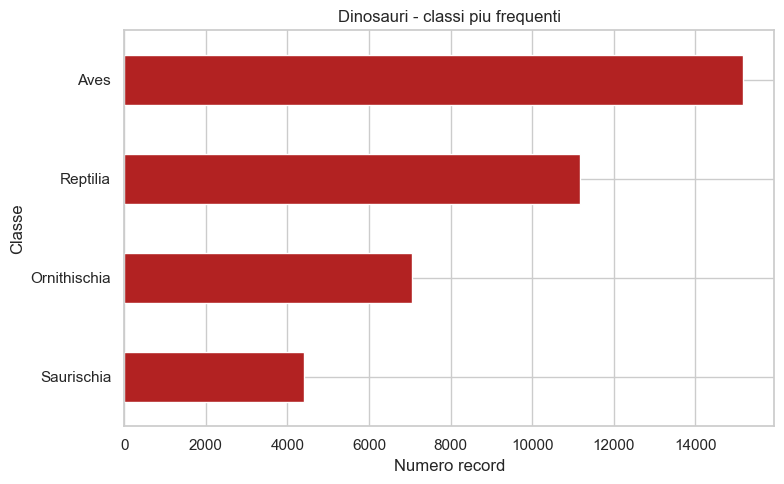

In [21]:
df_dino['class'].value_counts().head(10).sort_values().plot(kind='barh', color=rosso, figsize=(8, 5))
plt.title('Dinosauri - classi piu frequenti')
plt.xlabel('Numero record')
plt.ylabel('Classe')
plt.tight_layout()
plt.show()

#### 3.6.2 Grafico intervalli frequenti

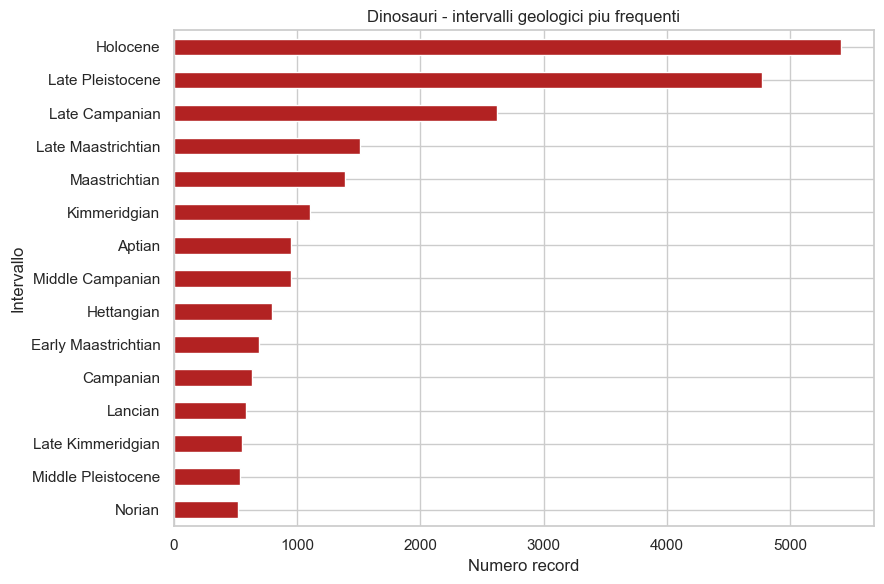

In [22]:
df_dino['early_interval'].value_counts().head(15).sort_values().plot(kind='barh', color=rosso, figsize=(9, 6))
plt.title('Dinosauri - intervalli geologici piu frequenti')
plt.xlabel('Numero record')
plt.ylabel('Intervallo')
plt.tight_layout()
plt.show()

#### 3.6.3 Istogramma eta

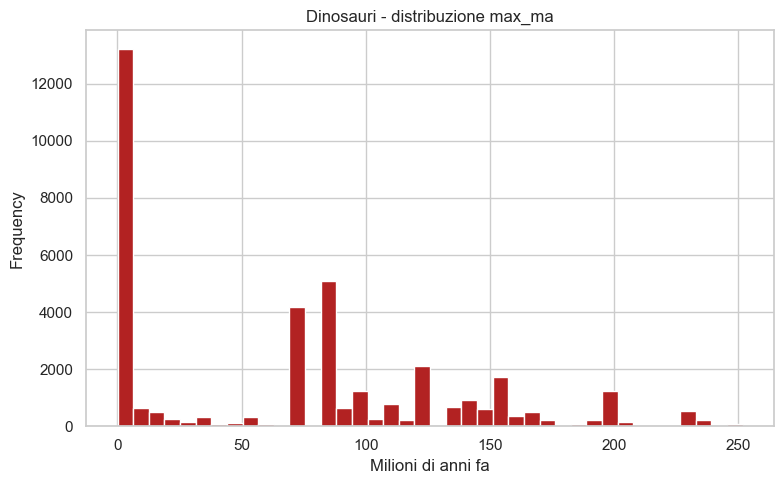

In [23]:
df_dino['max_ma'].dropna().plot(kind='hist', bins=40, color=rosso, figsize=(8, 5))
plt.title('Dinosauri - distribuzione max_ma')
plt.xlabel('Milioni di anni fa')
plt.tight_layout()
plt.show()

#### 3.6.4 Boxplot eta

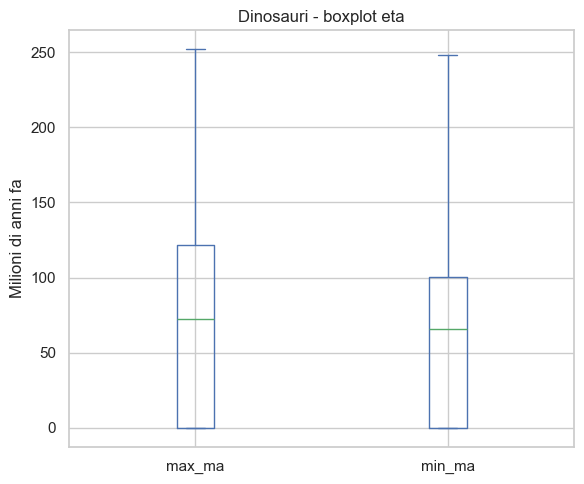

In [24]:
df_dino[['max_ma', 'min_ma']].plot(kind='box', figsize=(6, 5))
plt.title('Dinosauri - boxplot eta')
plt.ylabel('Milioni di anni fa')
plt.tight_layout()
plt.show()

### 3.7 Grafici Seaborn

Grafici un po' piu leggibili per riassumere le informazioni principali dei dinosauri.

#### 3.7.1 Grafico seaborn classi

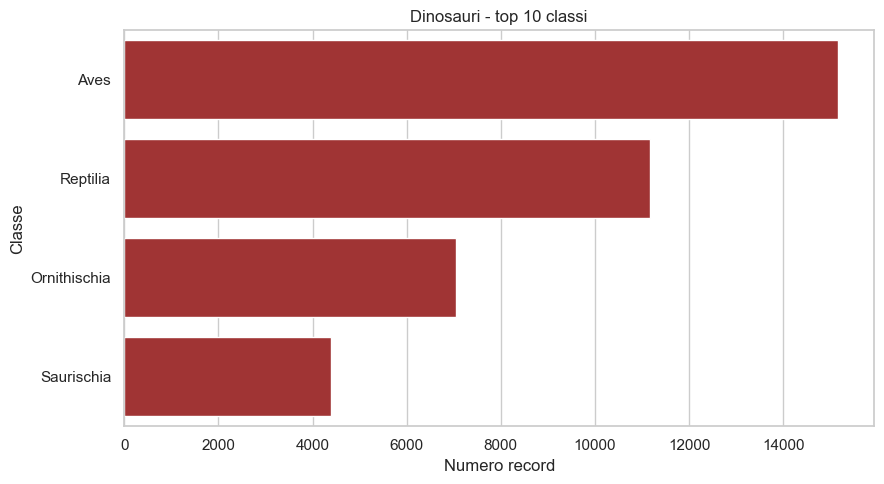

In [25]:
top_classi_dino = df_dino['class'].value_counts().head(10).reset_index()
top_classi_dino.columns = ['class', 'conteggio']

plt.figure(figsize=(9, 5))
sns.barplot(data=top_classi_dino, x='conteggio', y='class', color=rosso)
plt.title('Dinosauri - top 10 classi')
plt.xlabel('Numero record')
plt.ylabel('Classe')
plt.tight_layout()
plt.show()

#### 3.7.2 Grafico seaborn paesi

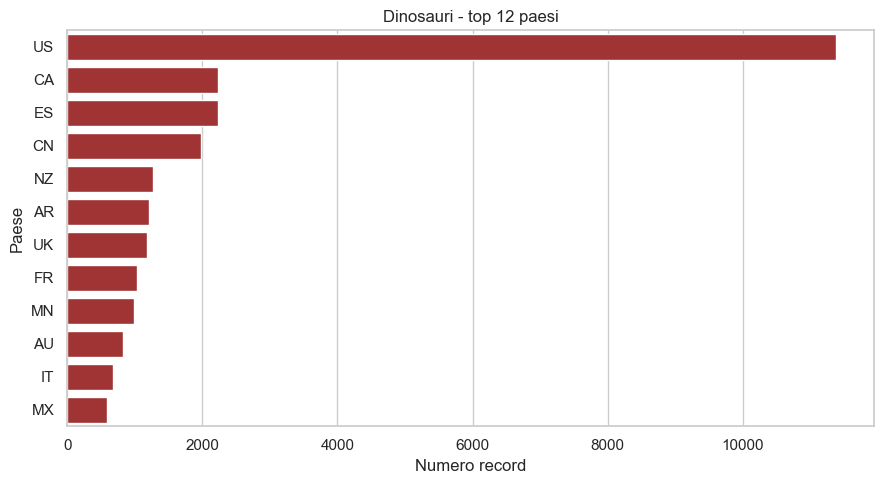

In [26]:
top_paesi_dino = df_dino['cc'].value_counts().head(12).reset_index()
top_paesi_dino.columns = ['cc', 'conteggio']

plt.figure(figsize=(9, 5))
sns.barplot(data=top_paesi_dino, x='conteggio', y='cc', color=rosso)
plt.title('Dinosauri - top 12 paesi')
plt.xlabel('Numero record')
plt.ylabel('Paese')
plt.tight_layout()
plt.show()

#### 3.7.3 Distribuzione temporale seaborn

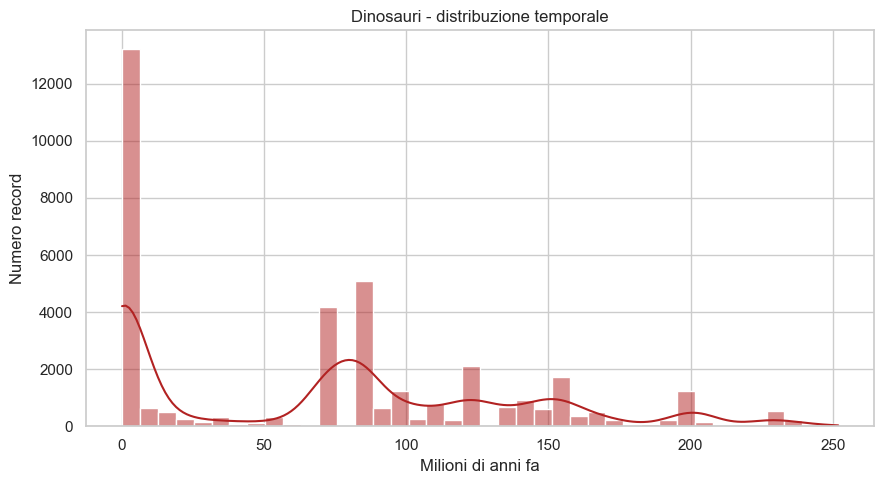

In [27]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df_dino, x='max_ma', bins=40, kde=True, color=rosso)
plt.title('Dinosauri - distribuzione temporale')
plt.xlabel('Milioni di anni fa')
plt.ylabel('Numero record')
plt.tight_layout()
plt.show()

#### 3.7.4 Boxplot eta per classi

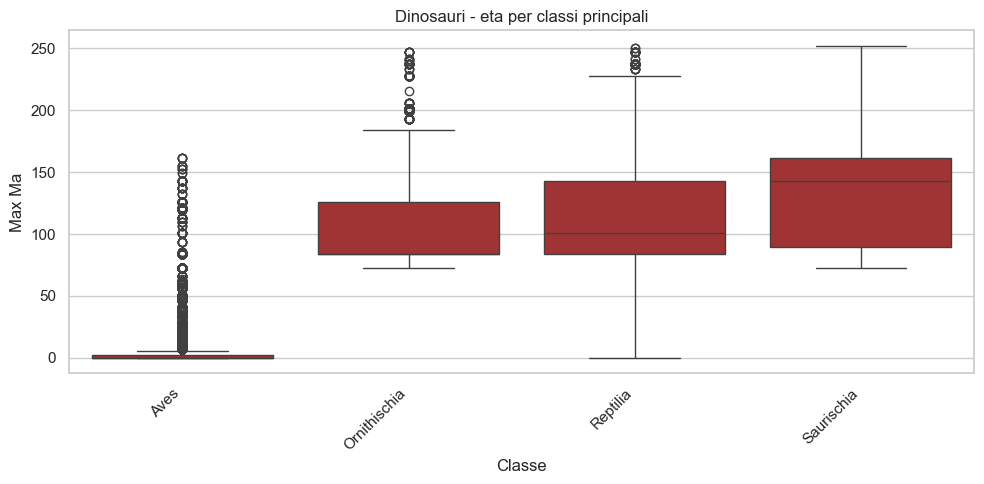

In [28]:
classi_top_dino = df_dino['class'].value_counts().head(5).index
df_dino_classi_top = df_dino[df_dino['class'].isin(classi_top_dino)]

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_dino_classi_top, x='class', y='max_ma', color=rosso)
plt.title('Dinosauri - eta per classi principali')
plt.xlabel('Classe')
plt.ylabel('Max Ma')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### 3.7.5 Coordinate geografiche

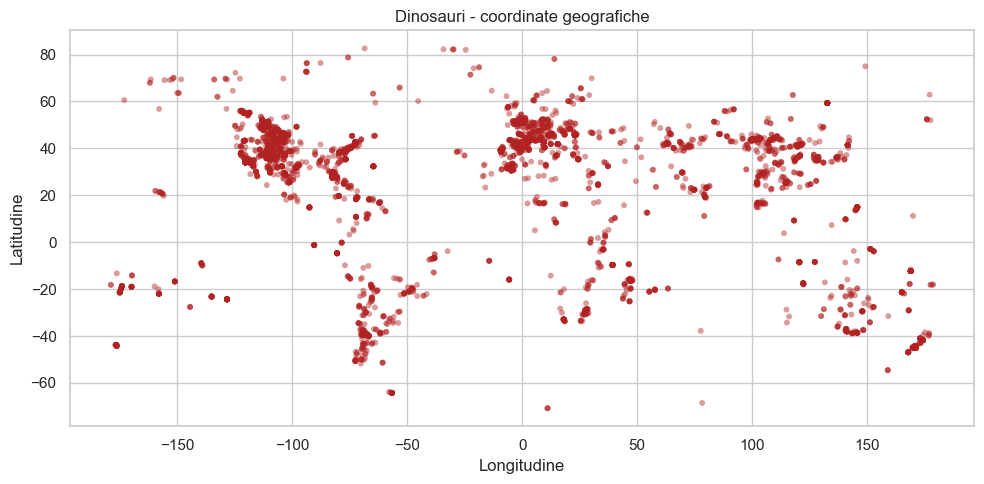

In [29]:
df_dino_geo_sns = df_dino.dropna(subset=['lng', 'lat'])
df_dino_geo_sns = df_dino_geo_sns[df_dino_geo_sns['lat'].between(-90, 90)]
df_dino_geo_sns = df_dino_geo_sns[df_dino_geo_sns['lng'].between(-180, 180)]

if len(df_dino_geo_sns) > 5000:
    df_dino_geo_sns = df_dino_geo_sns.sample(5000, random_state=1)

plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_dino_geo_sns, x='lng', y='lat', color=rosso, alpha=0.45, s=18, edgecolor='none')
plt.title('Dinosauri - coordinate geografiche')
plt.xlabel('Longitudine')
plt.ylabel('Latitudine')
plt.tight_layout()
plt.show()

## 4. EDA piante

### 4.1 Anteprima e struttura

#### 4.1.1 Prime righe piante

In [30]:
df_plants.head()

,occurrence_no,record_type,reid_no,flags,collection_no,identified_name,identified_rank,identified_no,difference,accepted_name,...,geogcomments,cx_int_no,formation,geological_group,member,phylum,class,order,family,genus
0,31284,occ,NaN,NaN,2260,Algae indet.,class,NaN,NaN,Algae,...,This is a collection based on a composite of t...,121.0,Alikper,NaN,NaN,NO_PHYLUM_SPECIFIED,Algae,NaN,NaN,NaN
1,45807,occ,NaN,NaN,3640,? Caryophyllidae indet.,subclass,NaN,NaN,Caryophyllidae,...,Pitt Island,39.0,Kahuitara Tuff,NaN,NaN,Angiospermae,Dicotyledoneae,NaN,NaN,NaN
2,77082,occ,NaN,NaN,1573,Plantae indet.,kingdom,NaN,NaN,Plantae,...,cliff below Sandsfoot Castle,126.0,Sandsfoot Grit,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,77169,occ,NaN,NaN,1567,Plantae indet.,kingdom,NaN,NaN,Plantae,...,cliff below Sandsfoot Castle,126.0,Sandsfoot Grit,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,82793,occ,NaN,NaN,1555,Diplopora versipora,genus,NaN,species not entered,Diplopora,...,coastal cliff between Black Head and Shortlake,126.0,Trigonia clavellata,NaN,NaN,Chlorophyta,Chlorophyceae,Dasycladales,Diploporaceae,Diplopora


#### 4.1.2 Info colonne piante

In [31]:
df_plants.info()

<class 'pandas.DataFrame'>
RangeIndex: 57394 entries, 0 to 57393
Data columns (total 38 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   occurrence_no     57394 non-null  int64  
 1   record_type       57394 non-null  str    
 2   reid_no           167 non-null    float64
 3   flags             14503 non-null  str    
 4   collection_no     57394 non-null  int64  
 5   identified_name   57394 non-null  str    
 6   identified_rank   57394 non-null  str    
 7   identified_no     3597 non-null   float64
 8   difference        11512 non-null  str    
 9   accepted_name     57394 non-null  str    
 10  accepted_attr     56253 non-null  str    
 11  accepted_rank     57394 non-null  str    
 12  accepted_no       57394 non-null  int64  
 13  early_interval    57394 non-null  str    
 14  late_interval     19454 non-null  str    
 15  max_ma            57394 non-null  float64
 16  min_ma            57394 non-null  float64
 17  refe

#### 4.1.3 Dimensioni dataset

In [32]:
df_plants.shape

(57394, 38)

### 4.2 Valori mancanti

#### 4.2.1 Conteggio valori nulli

In [33]:
df_plants.isnull().sum()

occurrence_no           0
record_type             0
reid_no             57227
flags               42891
collection_no           0
identified_name         0
identified_rank         0
identified_no       53797
difference          45882
accepted_name           0
accepted_attr        1141
accepted_rank           0
accepted_no             0
early_interval          0
late_interval       37940
max_ma                  0
min_ma                  0
reference_no            0
lng                     0
lat                     0
cc                      0
state               20247
county              46988
latlng_basis         4152
latlng_precision        0
altitude_value      51578
altitude_unit       52857
geogscale           30182
geogcomments        29262
cx_int_no              70
formation           12943
geological_group    49478
member              51137
phylum                482
class                1100
order                1847
family               2210
genus                2646
dtype: int64

#### 4.2.2 Percentuale valori nulli

In [34]:
(df_plants.isnull().sum() / len(df_plants) * 100).round(2)

occurrence_no        0.00
record_type          0.00
reid_no             99.71
flags               74.73
collection_no        0.00
identified_name      0.00
identified_rank      0.00
identified_no       93.73
difference          79.94
accepted_name        0.00
accepted_attr        1.99
accepted_rank        0.00
accepted_no          0.00
early_interval       0.00
late_interval       66.10
max_ma               0.00
min_ma               0.00
reference_no         0.00
lng                  0.00
lat                  0.00
cc                   0.00
state               35.28
county              81.87
latlng_basis         7.23
latlng_precision     0.00
altitude_value      89.87
altitude_unit       92.09
geogscale           52.59
geogcomments        50.98
cx_int_no            0.12
formation           22.55
geological_group    86.21
member              89.10
phylum               0.84
class                1.92
order                3.22
family               3.85
genus                4.61
dtype: float

#### 4.2.3 Colonne con piu valori nulli

In [35]:
nulli_plants = (df_plants.isnull().sum() / len(df_plants) * 100).sort_values(ascending=False).head(15)
nulli_plants

reid_no             99.709029
identified_no       93.732794
altitude_unit       92.094993
altitude_value      89.866537
member              89.098164
geological_group    86.207618
county              81.869185
difference          79.942154
flags               74.730808
late_interval       66.104471
geogscale           52.587378
geogcomments        50.984423
state               35.277207
formation           22.551138
latlng_basis         7.234206
dtype: float64

#### 4.2.4 Grafico valori mancanti

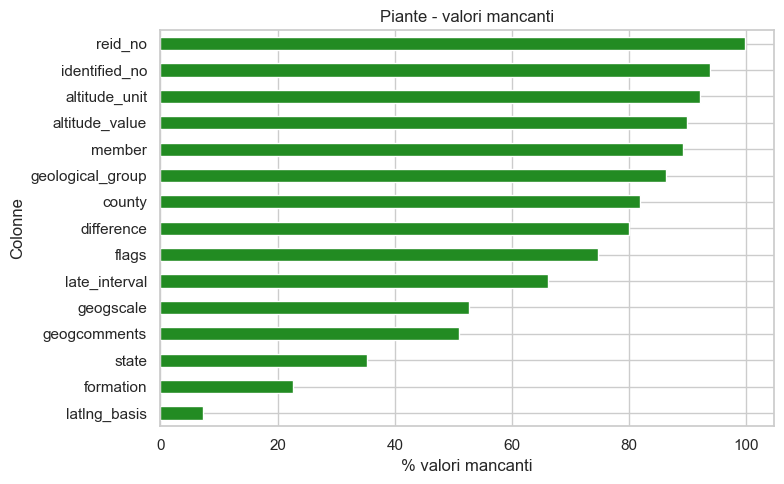

In [36]:
nulli_plants.sort_values().plot(kind='barh', color=verde, figsize=(8, 5))
plt.title('Piante - valori mancanti')
plt.xlabel('% valori mancanti')
plt.ylabel('Colonne')
plt.tight_layout()
plt.show()

### 4.3 Duplicati

#### 4.3.1 Controllo duplicati

In [37]:
df_plants.duplicated().sum()

np.int64(0)

#### 4.3.2 Rimozione duplicati

In [38]:
df_plants_clean = df_plants.drop_duplicates()
print(df_plants.shape)
print(df_plants_clean.shape)

(57394, 38)
(57394, 38)


### 4.4 Conteggi per categoria

#### 4.4.1 Conteggio classi

In [39]:
df_plants['class'].value_counts(dropna=False).head(15)

class
NO_CLASS_SPECIFIED    21096
Polypodiopsida        12665
Ginkgoopsida           4301
Equisetopsida          3355
Cycadopsida            2494
Pteridopsida           2149
Lycopodiopsida         1486
Chlorophyceae          1331
NaN                    1100
Gnetopsida             1016
Pinopsida               846
Dicotyledoneae          764
Magnoliopsida           623
Peltaspermopsida        614
Lyginopteridopsida      444
Name: count, dtype: int64

#### 4.4.2 Conteggio ordini

In [40]:
df_plants['order'].value_counts(dropna=False).head(15)

order
NO_ORDER_SPECIFIED    23150
Coniferales            4011
Bennettitales          3149
Cycadales              2300
Equisetales            1880
NaN                    1847
Ginkgoales             1545
Schizaeales            1314
Czekanowskiales        1243
Cyatheales             1222
Dasycladales           1221
Gleicheniales          1099
Ephedrales             1046
Pinales                 822
Proteales               724
Name: count, dtype: int64

#### 4.4.3 Conteggio famiglie

In [41]:
df_plants['family'].value_counts(dropna=False).head(15)

family
NO_FAMILY_SPECIFIED    29493
Podocarpaceae           2823
NaN                     2210
Araucariaceae           1929
Cyatheaceae             1216
Equisetaceae            1196
Schizaeaceae            1009
Ginkgoaceae              978
Cheirolepidiaceae        974
Gleicheniaceae           721
Osmundaceae              686
Polypodiaceae            675
Dasycladaceae            643
Dipteridaceae            637
Calamitaceae             570
Name: count, dtype: int64

#### 4.4.4 Conteggio generi

In [42]:
df_plants['genus'].value_counts(dropna=False).head(15)

genus
NaN                    2646
Cladophlebis           2364
Coniopteris            1173
Nilsonia               1007
Podozamites             924
Equisetites             878
Ephedripites            838
Classopollis            827
Pterophyllum            808
Cicatricosisporites     769
Cyathidites             717
Czekanowskia            584
Taeniopteris            576
Ginkgo                  567
Pityophyllum            546
Name: count, dtype: int64

#### 4.4.5 Conteggio paesi

In [43]:
df_plants['cc'].value_counts(dropna=False).head(15)

cc
RU    6208
US    6078
CN    5245
AR    4864
BR    3590
IN    2838
EG    2191
CA    2052
AU    1974
AQ    1638
UK    1539
TJ    1151
KZ     880
FR     863
RO     851
Name: count, dtype: int64

#### 4.4.6 Conteggio intervalli geologici

In [44]:
df_plants['early_interval'].value_counts(dropna=False).head(15)

early_interval
Late Jurassic      3395
Maastrichtian      3038
Albian             2846
Carnian            2510
Middle Jurassic    2284
Late Aptian        2238
Early Jurassic     2126
Aptian             1968
Norian             1957
Aalenian           1459
Early Albian       1445
Lancian            1421
Cenomanian         1398
Late Albian        1251
Bajocian           1202
Name: count, dtype: int64

### 4.5 Statistiche descrittive

#### 4.5.1 Statistiche descrittive

In [45]:
df_plants.describe()

,occurrence_no,reid_no,collection_no,identified_no,accepted_no,max_ma,min_ma,reference_no,lng,lat,altitude_value,cx_int_no
count,5.739400e+04,167.000000,57394.000000,3597.000000,57394.000000,57394.000000,57394.000000,57394.000000,57394.000000,57394.000000,5816.000000,57324.000000
mean,7.789207e+05,36764.209581,93396.743858,267378.837364,240363.784281,149.337731,135.531882,31231.252448,12.532439,22.700500,1013.094911,94.246703
std,5.282047e+05,6414.912459,76093.576926,159657.844253,131227.216724,55.096272,53.936862,28058.458710,80.320561,35.479272,1151.551682,104.602506
min,3.128400e+04,10001.000000,1555.000000,53526.000000,24832.000000,72.200000,0.000000,41.000000,-176.000000,-84.000000,-2637.000000,2.000000
25%,3.178562e+05,36545.500000,30236.000000,157259.000000,85569.000000,100.500000,93.900000,8169.000000,-68.006386,2.620556,261.000000,41.000000
50%,3.770765e+05,39595.000000,34796.000000,250494.000000,264632.000000,143.100000,121.400000,8854.000000,21.850000,36.540901,679.000000,112.000000
75%,1.194198e+06,40685.500000,150615.000000,447875.000000,319931.000000,192.900000,174.700000,48166.000000,79.000000,46.398056,1385.000000,119.000000
max,2.064923e+06,42570.000000,278854.000000,515009.000000,517594.000000,298.900000,250.500000,94878.000000,177.083328,81.949997,9050.000000,751.000000


#### 4.5.2 Statistiche colonne numeriche

In [46]:
df_plants[['max_ma', 'min_ma', 'lng', 'lat']].describe()

,max_ma,min_ma,lng,lat
count,57394.000000,57394.000000,57394.000000,57394.000000
mean,149.337731,135.531882,12.532439,22.700500
std,55.096272,53.936862,80.320561,35.479272
min,72.200000,0.000000,-176.000000,-84.000000
25%,100.500000,93.900000,-68.006386,2.620556
50%,143.100000,121.400000,21.850000,36.540901
75%,192.900000,174.700000,79.000000,46.398056
max,298.900000,250.500000,177.083328,81.949997


### 4.6 Visualizzazioni

#### 4.6.1 Grafico classi frequenti

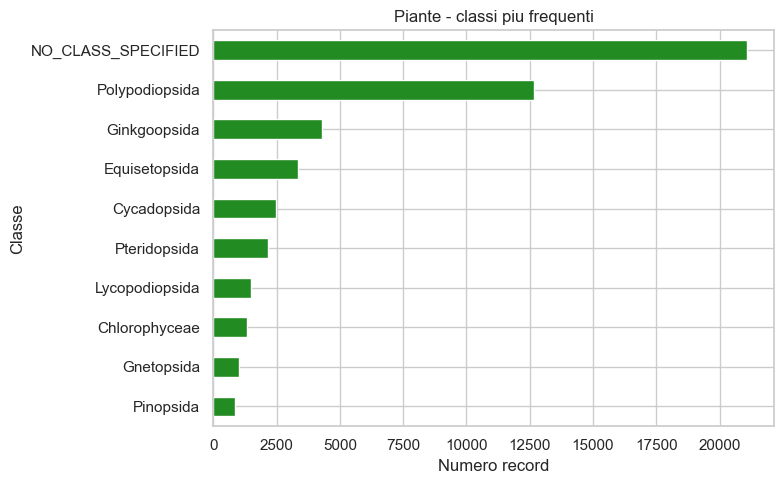

In [47]:
df_plants['class'].value_counts().head(10).sort_values().plot(kind='barh', color=verde, figsize=(8, 5))
plt.title('Piante - classi piu frequenti')
plt.xlabel('Numero record')
plt.ylabel('Classe')
plt.tight_layout()
plt.show()

#### 4.6.2 Grafico intervalli frequenti

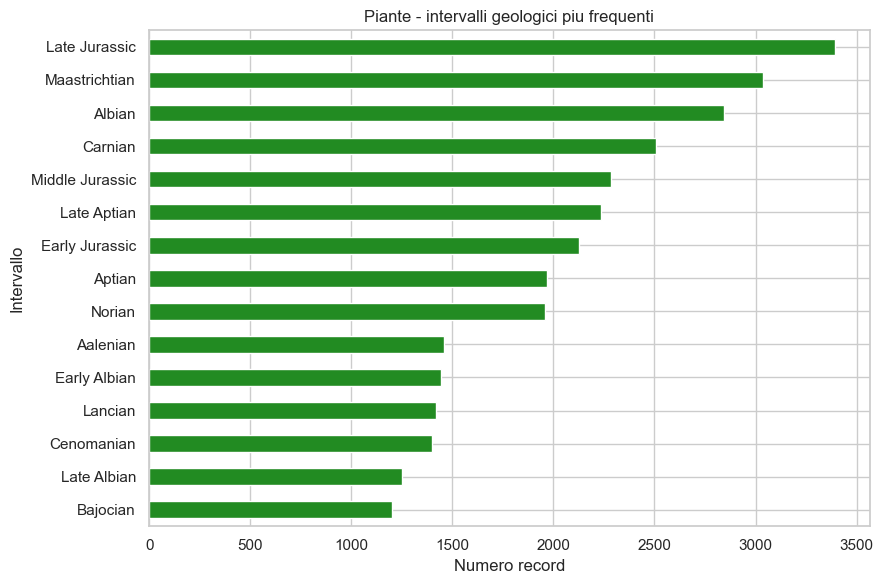

In [48]:
df_plants['early_interval'].value_counts().head(15).sort_values().plot(kind='barh', color=verde, figsize=(9, 6))
plt.title('Piante - intervalli geologici piu frequenti')
plt.xlabel('Numero record')
plt.ylabel('Intervallo')
plt.tight_layout()
plt.show()

#### 4.6.3 Istogramma eta

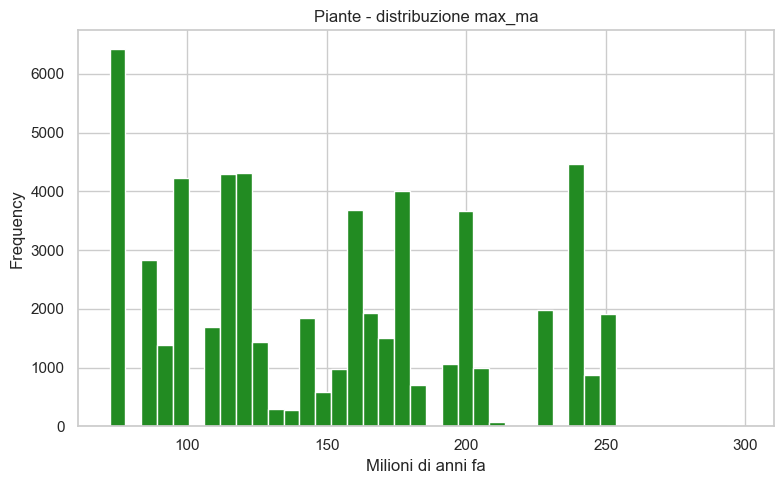

In [49]:
df_plants['max_ma'].dropna().plot(kind='hist', bins=40, color=verde, figsize=(8, 5))
plt.title('Piante - distribuzione max_ma')
plt.xlabel('Milioni di anni fa')
plt.tight_layout()
plt.show()

#### 4.6.4 Boxplot eta

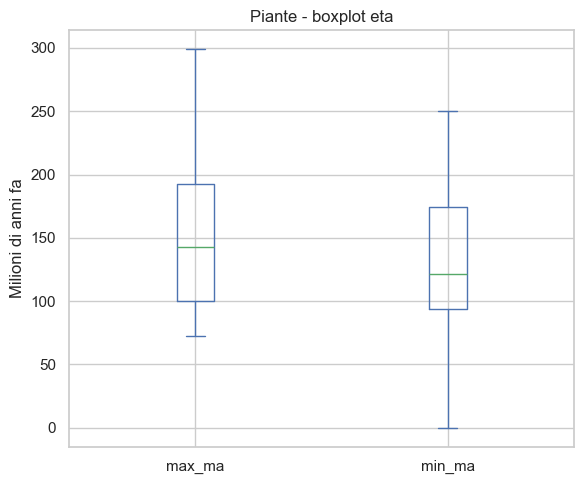

In [50]:
df_plants[['max_ma', 'min_ma']].plot(kind='box', figsize=(6, 5))
plt.title('Piante - boxplot eta')
plt.ylabel('Milioni di anni fa')
plt.tight_layout()
plt.show()

### 4.7 Grafici Seaborn

Stessi grafici dei dinosauri, applicati alle piante.

#### 4.7.1 Grafico seaborn classi

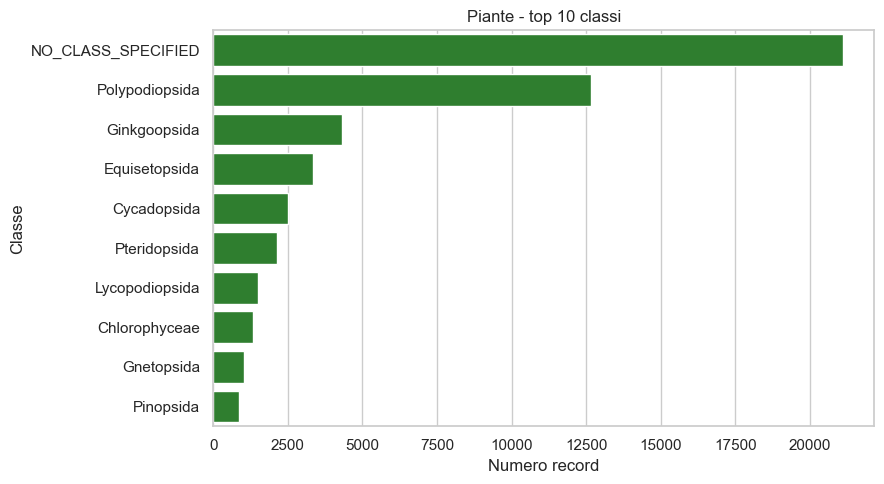

In [51]:
top_classi_plants = df_plants['class'].value_counts().head(10).reset_index()
top_classi_plants.columns = ['class', 'conteggio']

plt.figure(figsize=(9, 5))
sns.barplot(data=top_classi_plants, x='conteggio', y='class', color=verde)
plt.title('Piante - top 10 classi')
plt.xlabel('Numero record')
plt.ylabel('Classe')
plt.tight_layout()
plt.show()

#### 4.7.2 Grafico seaborn paesi

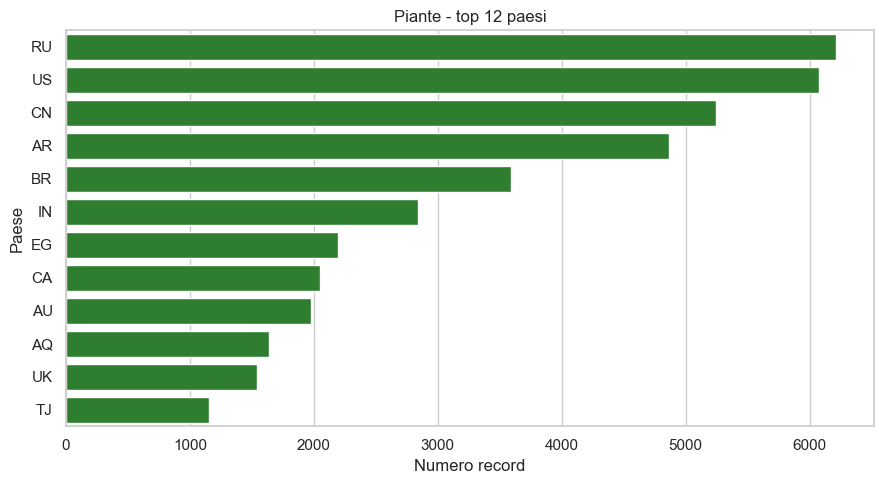

In [52]:
top_paesi_plants = df_plants['cc'].value_counts().head(12).reset_index()
top_paesi_plants.columns = ['cc', 'conteggio']

plt.figure(figsize=(9, 5))
sns.barplot(data=top_paesi_plants, x='conteggio', y='cc', color=verde)
plt.title('Piante - top 12 paesi')
plt.xlabel('Numero record')
plt.ylabel('Paese')
plt.tight_layout()
plt.show()

#### 4.7.3 Distribuzione temporale seaborn

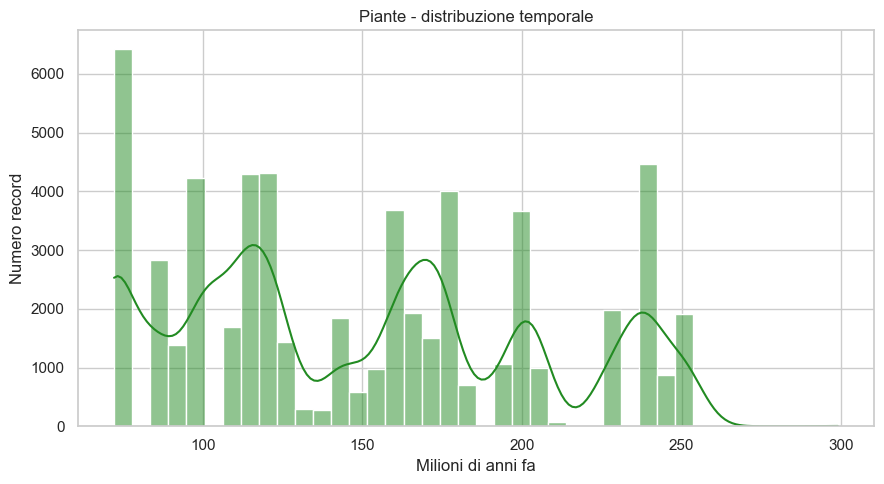

In [53]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df_plants, x='max_ma', bins=40, kde=True, color=verde)
plt.title('Piante - distribuzione temporale')
plt.xlabel('Milioni di anni fa')
plt.ylabel('Numero record')
plt.tight_layout()
plt.show()

#### 4.7.4 Boxplot eta per classi

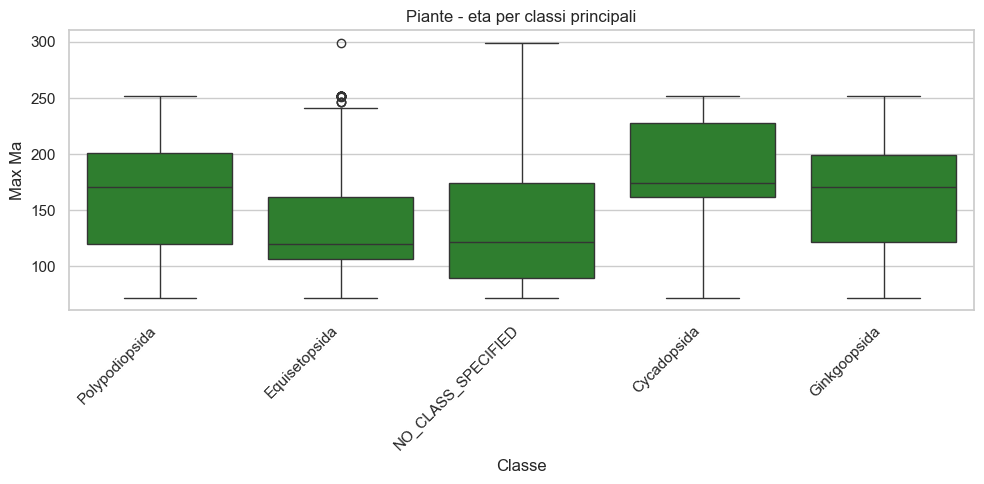

In [54]:
classi_top_plants = df_plants['class'].value_counts().head(5).index
df_plants_classi_top = df_plants[df_plants['class'].isin(classi_top_plants)]

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_plants_classi_top, x='class', y='max_ma', color=verde)
plt.title('Piante - eta per classi principali')
plt.xlabel('Classe')
plt.ylabel('Max Ma')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### 4.7.5 Coordinate geografiche

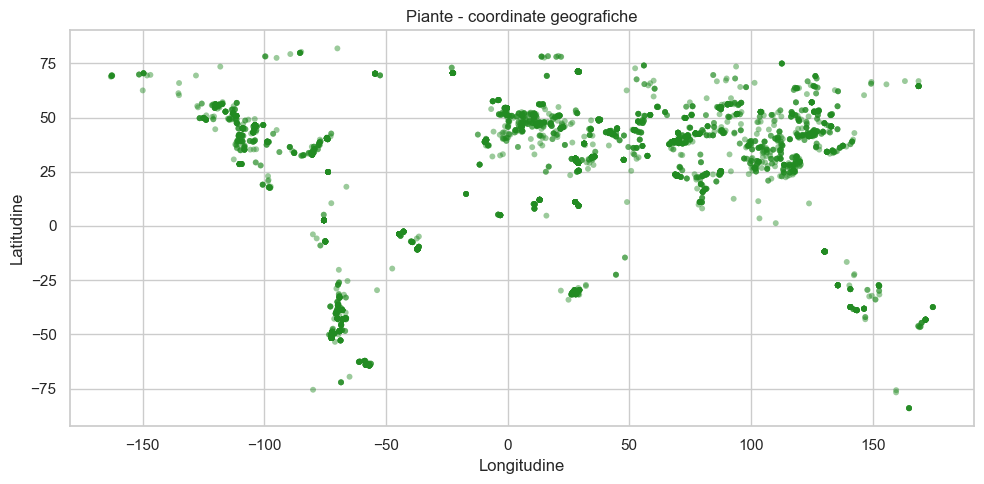

In [55]:
df_plants_geo_sns = df_plants.dropna(subset=['lng', 'lat'])
df_plants_geo_sns = df_plants_geo_sns[df_plants_geo_sns['lat'].between(-90, 90)]
df_plants_geo_sns = df_plants_geo_sns[df_plants_geo_sns['lng'].between(-180, 180)]

if len(df_plants_geo_sns) > 5000:
    df_plants_geo_sns = df_plants_geo_sns.sample(5000, random_state=1)

plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_plants_geo_sns, x='lng', y='lat', color=verde, alpha=0.45, s=18, edgecolor='none')
plt.title('Piante - coordinate geografiche')
plt.xlabel('Longitudine')
plt.ylabel('Latitudine')
plt.tight_layout()
plt.show()

## 5. EDA confronto dinosauri-piante

### 5.1 Confronto base

#### 5.1.1 Tabella confronto generale

In [56]:
confronto = pd.DataFrame({
    'dataset': ['dinosauri', 'piante'],
    'righe': [len(df_dino), len(df_plants)],
    'colonne': [df_dino.shape[1], df_plants.shape[1]],
    'generi': [df_dino['genus'].nunique(), df_plants['genus'].nunique()],
    'famiglie': [df_dino['family'].nunique(), df_plants['family'].nunique()],
    'paesi': [df_dino['cc'].nunique(), df_plants['cc'].nunique()]
})

confronto

,dataset,righe,colonne,generi,famiglie,paesi
0,dinosauri,37790,38,3082,409,168
1,piante,57394,38,1845,248,118


#### 5.1.2 Grafico numero record

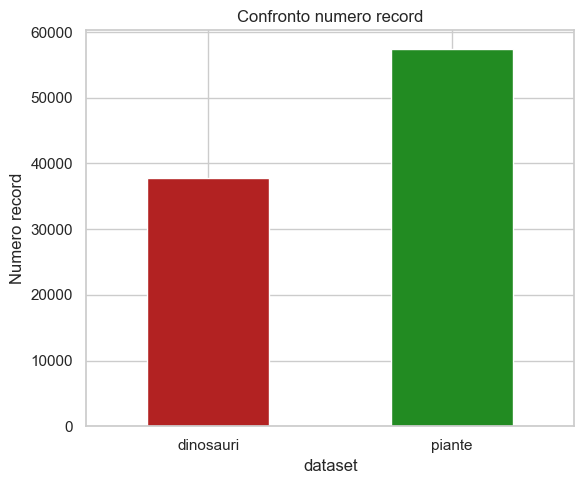

In [57]:
confronto.plot(kind='bar', x='dataset', y='righe', color=[rosso, verde], legend=False, figsize=(6, 5))
plt.title('Confronto numero record')
plt.ylabel('Numero record')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### 5.1.3 Tabella confronto nulli

In [58]:
nulli_confronto = pd.DataFrame({
    'dinosauri': (df_dino.isnull().sum() / len(df_dino) * 100).round(2),
    'piante': (df_plants.isnull().sum() / len(df_plants) * 100).round(2)
})

nulli_confronto.sort_values('dinosauri', ascending=False).head(15)

,dinosauri,piante
flags,90.96,74.73
difference,89.71,79.94
reid_no,89.01,99.71
member,80.93,89.10
altitude_unit,77.30,92.09
altitude_value,77.06,89.87
late_interval,77.04,66.10
geological_group,72.61,86.21
identified_no,66.39,93.73
county,50.44,81.87


#### 5.1.4 Grafico confronto nulli

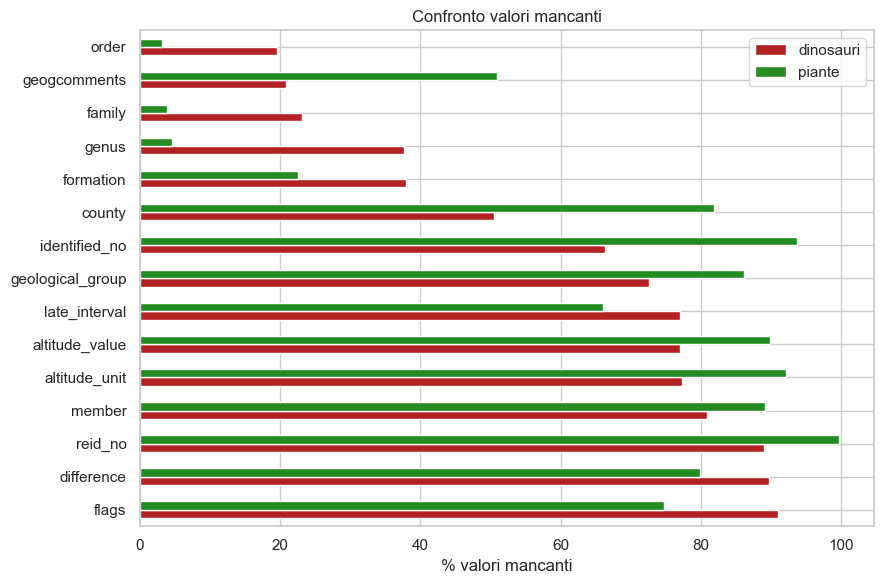

In [59]:
nulli_confronto.sort_values('dinosauri', ascending=False).head(15).plot(kind='barh', color=[rosso, verde], figsize=(9, 6))
plt.title('Confronto valori mancanti')
plt.xlabel('% valori mancanti')
plt.tight_layout()
plt.show()

#### 5.1.5 Confronto distribuzione eta

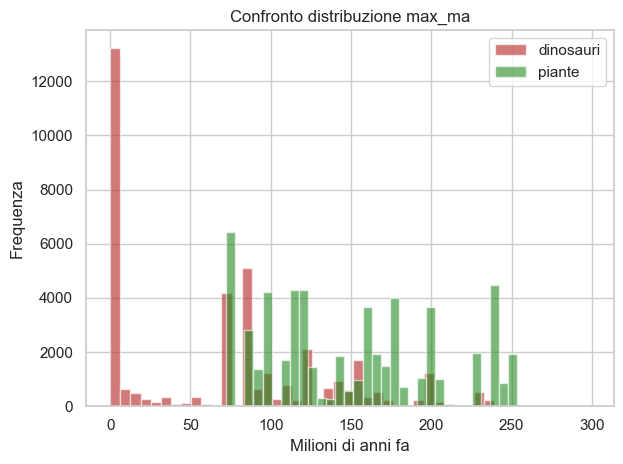

In [60]:
plt.hist(df_dino['max_ma'].dropna(), bins=40, alpha=0.6, color=rosso, label='dinosauri')
plt.hist(df_plants['max_ma'].dropna(), bins=40, alpha=0.6, color=verde, label='piante')
plt.title('Confronto distribuzione max_ma')
plt.xlabel('Milioni di anni fa')
plt.ylabel('Frequenza')
plt.legend()
plt.tight_layout()
plt.show()

#### 5.1.6 Tabella confronto paesi

In [61]:
paesi = pd.DataFrame({
    'dinosauri': df_dino['cc'].value_counts(),
    'piante': df_plants['cc'].value_counts()
}).fillna(0)

paesi['totale'] = paesi['dinosauri'] + paesi['piante']
paesi.sort_values('totale', ascending=False).head(15)

,dinosauri,piante,totale
cc,,,
US,11377.0,6078.0,17455.0
CN,1975.0,5245.0,7220.0
RU,385.0,6208.0,6593.0
AR,1215.0,4864.0,6079.0
CA,2225.0,2052.0,4277.0
BR,582.0,3590.0,4172.0
IN,292.0,2838.0,3130.0
AU,830.0,1974.0,2804.0
UK,1184.0,1539.0,2723.0


#### 5.1.7 Grafico confronto paesi

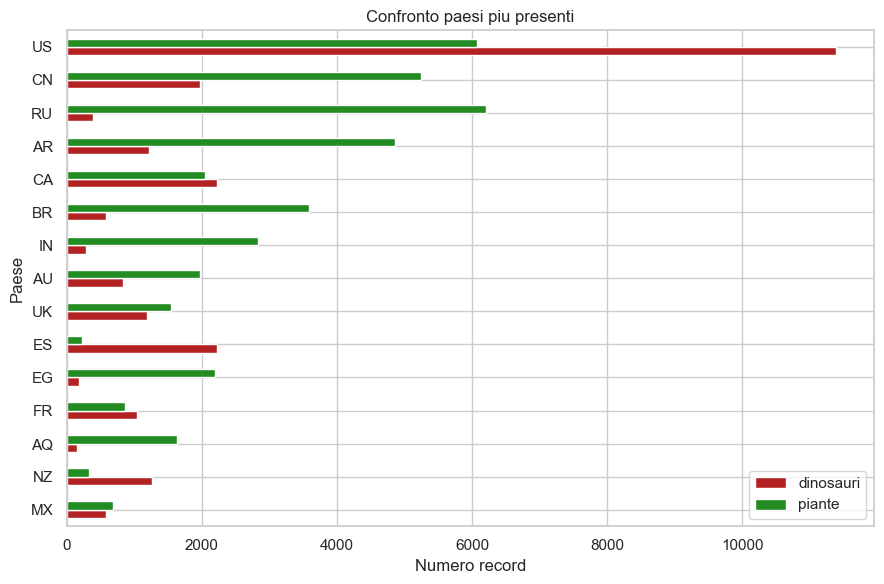

In [62]:
paesi_top15 = paesi.sort_values('totale', ascending=False).head(15)
paesi_top15 = paesi_top15.sort_values('totale')

paesi_top15[['dinosauri', 'piante']].plot(kind='barh', color=[rosso, verde], figsize=(9, 6))
plt.title('Confronto paesi piu presenti')
plt.xlabel('Numero record')
plt.ylabel('Paese')
plt.tight_layout()
plt.show()

### 5.2 Grafici Seaborn di confronto

Grafici di confronto tra i due dataset, usando sempre rosso per dinosauri e verde per piante.

#### 5.2.1 Grafico metriche principali

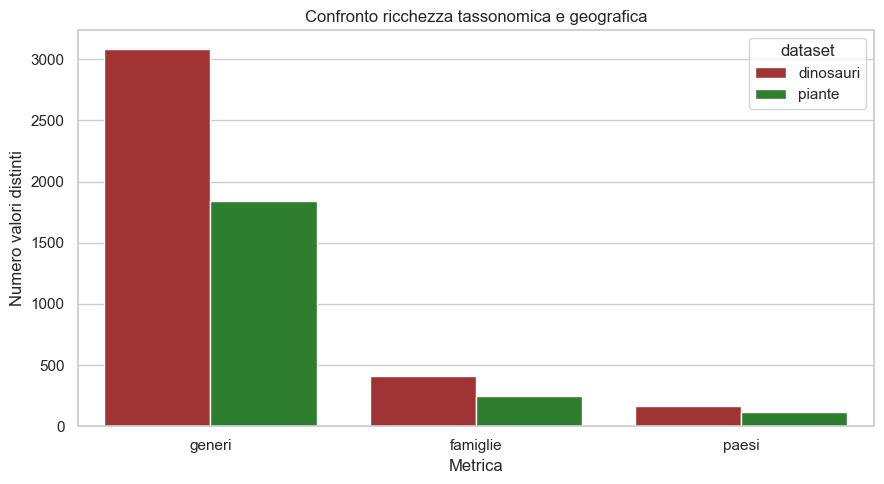

In [63]:
confronto_lungo = confronto.melt(
    id_vars='dataset',
    value_vars=['generi', 'famiglie', 'paesi'],
    var_name='metrica',
    value_name='valore'
)

plt.figure(figsize=(9, 5))
sns.barplot(data=confronto_lungo, x='metrica', y='valore', hue='dataset', palette=[rosso, verde])
plt.title('Confronto ricchezza tassonomica e geografica')
plt.xlabel('Metrica')
plt.ylabel('Numero valori distinti')
plt.tight_layout()
plt.show()

#### 5.2.2 Confronto distribuzione eta seaborn

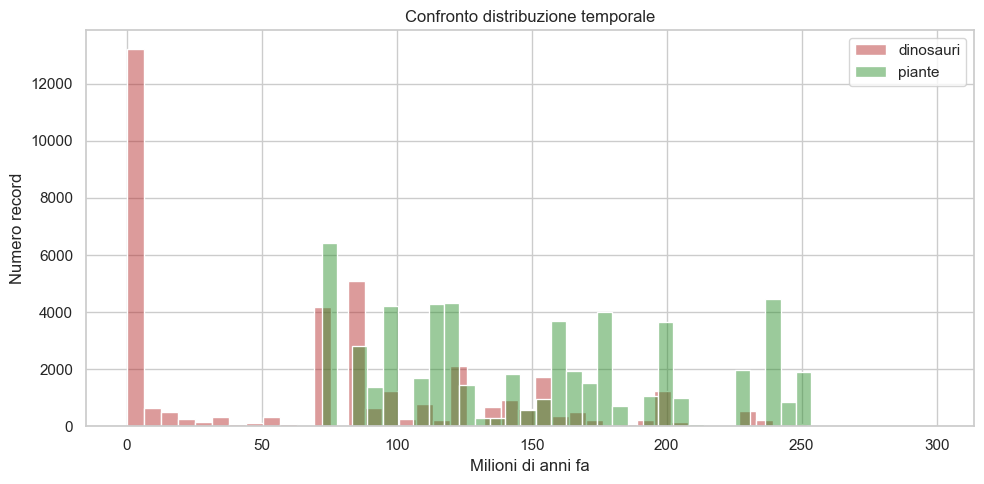

In [64]:
plt.figure(figsize=(10, 5))
sns.histplot(df_dino['max_ma'].dropna(), bins=40, color=rosso, alpha=0.45, label='dinosauri')
sns.histplot(df_plants['max_ma'].dropna(), bins=40, color=verde, alpha=0.45, label='piante')
plt.title('Confronto distribuzione temporale')
plt.xlabel('Milioni di anni fa')
plt.ylabel('Numero record')
plt.legend()
plt.tight_layout()
plt.show()

#### 5.2.3 Grafico seaborn paesi

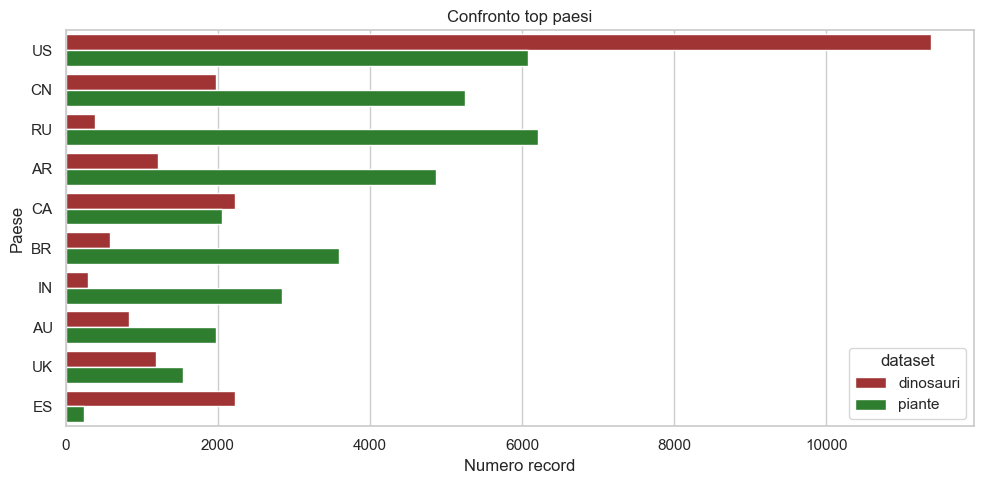

In [65]:
paesi_top = paesi.sort_values('totale', ascending=False).head(10)[['dinosauri', 'piante']].reset_index()
paesi_top = paesi_top.rename(columns={'index': 'cc'})
paesi_top_lungo = paesi_top.melt(id_vars='cc', var_name='dataset', value_name='record')

plt.figure(figsize=(10, 5))
sns.barplot(data=paesi_top_lungo, x='record', y='cc', hue='dataset', palette=[rosso, verde])
plt.title('Confronto top paesi')
plt.xlabel('Numero record')
plt.ylabel('Paese')
plt.tight_layout()
plt.show()

## 6. Feature engineering

Creo poche colonne nuove utili per continuare il progetto, senza fare trasformazioni troppo complesse.

### 6.1 Preparazione dataset unito

#### 6.1.1 Unione dinosauri e piante

In [66]:
df_fossili = pd.concat([df_dino, df_plants], ignore_index=True)

df_fossili['origine_dataset'] = ['dinosauri'] * len(df_dino) + ['piante'] * len(df_plants)

df_fossili.shape

(95184, 39)

#### 6.1.2 Anteprima dataset unito

In [67]:
df_fossili.head()

,occurrence_no,record_type,reid_no,flags,collection_no,identified_name,identified_rank,identified_no,difference,accepted_name,...,cx_int_no,formation,geological_group,member,phylum,class,order,family,genus,origine_dataset
0,41524,occ,NaN,NaN,3257,Aves indet.,class,NaN,NaN,Aves,...,37.0,NaN,Bracklesham,NaN,Chordata,Aves,NaN,NaN,NaN,dinosauri
1,41580,occ,NaN,NaN,3256,Aves indet.,class,NaN,NaN,Aves,...,37.0,NaN,Bracklesham,NaN,Chordata,Aves,NaN,NaN,NaN,dinosauri
2,130209,occ,NaN,NaN,10755,Chaoyangosaurus liaosiensis n. gen. n. sp.,species,65704.0,NaN,Chaoyangsaurus youngi,...,2.0,Tuchengzi,NaN,NaN,Chordata,Ornithischia,NO_ORDER_SPECIFIED,Chaoyangsauridae,Chaoyangsaurus,dinosauri
3,130294,occ,NaN,NaN,10764,Protarchaeopteryx robusta n. gen. n. sp.,species,NaN,NaN,Protarchaeopteryx robusta,...,40.0,Yixian,Jehol,Jianshangou,Chordata,Reptilia,NO_ORDER_SPECIFIED,NO_FAMILY_SPECIFIED,Protarchaeopteryx,dinosauri
4,130295,occ,NaN,NaN,10764,Caudipteryx zoui n. gen. n. sp.,species,NaN,NaN,Caudipteryx zoui,...,40.0,Yixian,Jehol,Jianshangou,Chordata,Reptilia,NO_ORDER_SPECIFIED,NO_FAMILY_SPECIFIED,Caudipteryx,dinosauri


#### 6.1.3 Scelta colonne utili

In [68]:
colonne_utili = [
    'occurrence_no', 'collection_no', 'accepted_name', 'accepted_rank',
    'early_interval', 'late_interval', 'max_ma', 'min_ma',
    'lng', 'lat', 'cc', 'state', 'formation', 'geological_group',
    'phylum', 'class', 'order', 'family', 'genus', 'origine_dataset'
]

df_fossili_clean = df_fossili[colonne_utili].copy()
df_fossili_clean.shape

(95184, 20)

#### 6.1.4 Filtro dinosauri non aviani

In [69]:
# Rimuovo Aves dai dinosauri.
df_fossili_clean = df_fossili_clean[~((df_fossili_clean['origine_dataset'] == 'dinosauri') & (df_fossili_clean['class'] == 'Aves'))].copy()
df_fossili_clean.shape

(80011, 20)

#### 6.1.5 Pulizia valori finti nulli

In [70]:
# Sostituisco alcuni valori finti nulli con NaN.
valori_finti_nulli = [
    'NO_ORDER_SPECIFIED',
    'NO_FAMILY_SPECIFIED',
    'NO_GENUS_SPECIFIED',
    'NO_CLASS_SPECIFIED',
    'NO_PHYLUM_SPECIFIED'
]

df_fossili_clean = df_fossili_clean.replace(valori_finti_nulli, np.nan)

#### 6.1.6 Controllo origine dataset

In [71]:
# Controllo del dataset unico dopo le prime modifiche.
df_fossili_clean['origine_dataset'].value_counts()

origine_dataset
piante       57394
dinosauri    22617
Name: count, dtype: int64

#### 6.1.7 Creazione eta media e range

In [72]:
# Eta media e ampiezza dell'intervallo
df_fossili_clean['eta_media_ma'] = (df_fossili_clean['max_ma'] + df_fossili_clean['min_ma']) / 2
df_fossili_clean['range_temporale_ma'] = df_fossili_clean['max_ma'] - df_fossili_clean['min_ma']

#### 6.1.8 Creazione periodo mesozoico

In [73]:
# Periodo geologico semplificato
df_fossili_clean['periodo_mesozoico'] = 'Altro'
df_fossili_clean.loc[(df_fossili_clean['max_ma'] >= 66) & (df_fossili_clean['max_ma'] < 145), 'periodo_mesozoico'] = 'Cretaceo'
df_fossili_clean.loc[(df_fossili_clean['max_ma'] >= 145) & (df_fossili_clean['max_ma'] < 201.3), 'periodo_mesozoico'] = 'Giurassico'
df_fossili_clean.loc[(df_fossili_clean['max_ma'] >= 201.3) & (df_fossili_clean['max_ma'] <= 252), 'periodo_mesozoico'] = 'Triassico' 

#### 6.1.9 Coordinate presenti

In [74]:
# Coordinate presenti
df_fossili_clean['coordinate_presenti'] = df_fossili_clean['lat'].notnull() & df_fossili_clean['lng'].notnull()

#### 6.1.10 Completezza tassonomica

In [75]:
# Completezza tassonomica: conto quanti campi tassonomici sono valorizzati
df_fossili_clean['completezza_tassonomica'] = df_fossili_clean[['phylum', 'class', 'order', 'family', 'genus']].notnull().sum(axis=1)

### 6.2 Feature aggiuntive

Aggiungo qualche feature in piu, utile per analisi successive ma ancora semplice da leggere.

#### 6.2.1 Coordinate valide

In [76]:
# Coordinate valide: controllo anche che latitudine e longitudine siano in range possibile.
df_fossili_clean['coordinate_valide'] = (
    df_fossili_clean['lat'].between(-90, 90)
    & df_fossili_clean['lng'].between(-180, 180)
    & df_fossili_clean['coordinate_presenti']
)

#### 6.2.2 Creazione emisfero

In [77]:
# Emisfero in base alla latitudine.
df_fossili_clean['emisfero'] = 'Sconosciuto'
df_fossili_clean.loc[df_fossili_clean['lat'] >= 0, 'emisfero'] = 'Nord'
df_fossili_clean.loc[df_fossili_clean['lat'] < 0, 'emisfero'] = 'Sud'

#### 6.2.3 Creazione fascia latitudine

In [78]:
# Fascia latitudine semplice.
df_fossili_clean['fascia_latitudine'] = 'Sconosciuta'
df_fossili_clean.loc[df_fossili_clean['lat'].between(-23.5, 23.5), 'fascia_latitudine'] = 'Tropicale'
df_fossili_clean.loc[df_fossili_clean['lat'].between(23.5, 66.5), 'fascia_latitudine'] = 'Temperata Nord'
df_fossili_clean.loc[df_fossili_clean['lat'].between(-66.5, -23.5), 'fascia_latitudine'] = 'Temperata Sud'
df_fossili_clean.loc[df_fossili_clean['lat'] > 66.5, 'fascia_latitudine'] = 'Polare Nord'
df_fossili_clean.loc[df_fossili_clean['lat'] < -66.5, 'fascia_latitudine'] = 'Polare Sud'

#### 6.2.4 Taxonomia completa

In [79]:
# Flag sulla tassonomia completa.
df_fossili_clean['taxonomia_completa'] = df_fossili_clean['completezza_tassonomica'] == 5

#### 6.2.5 Precisione temporale

In [80]:
# Lunghezza del range temporale divisa in classi semplici.
df_fossili_clean['precisione_temporale'] = 'Ampia'
df_fossili_clean.loc[df_fossili_clean['range_temporale_ma'] <= 5, 'precisione_temporale'] = 'Alta'
df_fossili_clean.loc[(df_fossili_clean['range_temporale_ma'] > 5) & (df_fossili_clean['range_temporale_ma'] <= 20), 'precisione_temporale'] = 'Media'

#### 6.2.6 Anteprima nuove feature

In [81]:
df_fossili_clean[[
    'origine_dataset', 'periodo_mesozoico', 'eta_media_ma', 'range_temporale_ma',
    'coordinate_presenti', 'coordinate_valide', 'emisfero', 'fascia_latitudine',
    'completezza_tassonomica', 'taxonomia_completa', 'precisione_temporale'
]].head()

,origine_dataset,periodo_mesozoico,eta_media_ma,range_temporale_ma,coordinate_presenti,coordinate_valide,emisfero,fascia_latitudine,completezza_tassonomica,taxonomia_completa,precisione_temporale
2,dinosauri,Giurassico,142.405,19.61,True,True,Nord,Temperata Nord,4,False,Media
3,dinosauri,Cretaceo,122.670,6.20,True,True,Nord,Temperata Nord,3,False,Media
4,dinosauri,Cretaceo,122.670,6.20,True,True,Nord,Temperata Nord,3,False,Media
5,dinosauri,Cretaceo,77.900,11.40,True,True,Nord,Temperata Nord,2,False,Media
6,dinosauri,Cretaceo,128.150,29.90,True,True,Nord,Temperata Nord,2,False,Ampia


#### 6.2.7 Riepilogo feature per dataset

In [82]:
df_fossili_clean.groupby('origine_dataset')[[
    'coordinate_presenti', 'coordinate_valide', 'taxonomia_completa', 'completezza_tassonomica'
]].mean().round(2)

,coordinate_presenti,coordinate_valide,taxonomia_completa,completezza_tassonomica
origine_dataset,,,,
dinosauri,1.0,1.0,0.04,3.06
piante,1.0,1.0,0.21,3.52


#### 6.2.8 Conteggio precisione temporale

In [83]:
df_fossili_clean['precisione_temporale'].value_counts()

precisione_temporale
Media    54566
Ampia    12832
Alta     12613
Name: count, dtype: int64

#### 6.2.9 Grafico completezza tassonomica

C:\Users\danilo.re\AppData\Local\Temp\2\ipykernel_18584\170396049.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_fossili_clean, x='origine_dataset', y='completezza_tassonomica', palette=[rosso, verde])


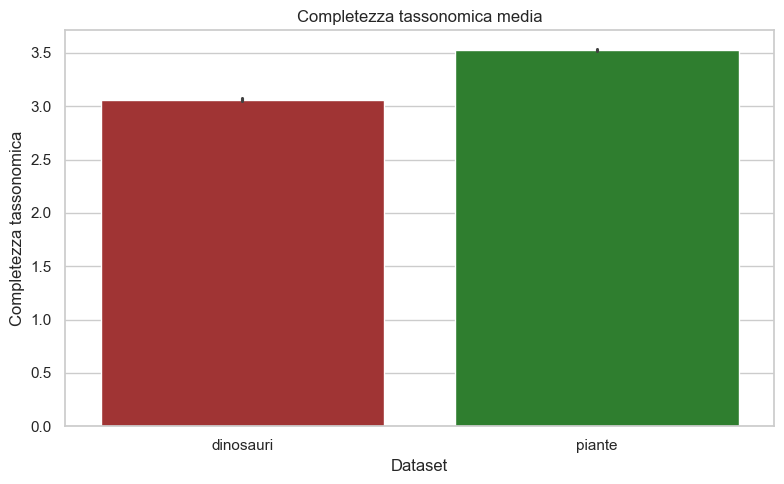

In [84]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df_fossili_clean, x='origine_dataset', y='completezza_tassonomica', palette=[rosso, verde])
plt.title('Completezza tassonomica media')
plt.xlabel('Dataset')
plt.ylabel('Completezza tassonomica')
plt.tight_layout()
plt.show()

#### 6.2.10 Grafico periodi mesozoici

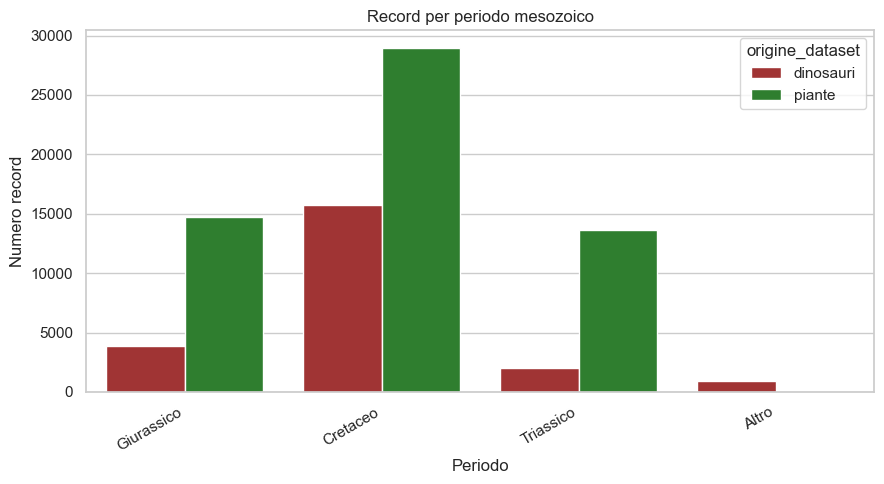

In [85]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df_fossili_clean, x='periodo_mesozoico', hue='origine_dataset', palette=[rosso, verde])
plt.title('Record per periodo mesozoico')
plt.xlabel('Periodo')
plt.ylabel('Numero record')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

#### 6.2.11 Anteprima dataset unito

In [86]:
df_fossili.head()

,occurrence_no,record_type,reid_no,flags,collection_no,identified_name,identified_rank,identified_no,difference,accepted_name,...,cx_int_no,formation,geological_group,member,phylum,class,order,family,genus,origine_dataset
0,41524,occ,NaN,NaN,3257,Aves indet.,class,NaN,NaN,Aves,...,37.0,NaN,Bracklesham,NaN,Chordata,Aves,NaN,NaN,NaN,dinosauri
1,41580,occ,NaN,NaN,3256,Aves indet.,class,NaN,NaN,Aves,...,37.0,NaN,Bracklesham,NaN,Chordata,Aves,NaN,NaN,NaN,dinosauri
2,130209,occ,NaN,NaN,10755,Chaoyangosaurus liaosiensis n. gen. n. sp.,species,65704.0,NaN,Chaoyangsaurus youngi,...,2.0,Tuchengzi,NaN,NaN,Chordata,Ornithischia,NO_ORDER_SPECIFIED,Chaoyangsauridae,Chaoyangsaurus,dinosauri
3,130294,occ,NaN,NaN,10764,Protarchaeopteryx robusta n. gen. n. sp.,species,NaN,NaN,Protarchaeopteryx robusta,...,40.0,Yixian,Jehol,Jianshangou,Chordata,Reptilia,NO_ORDER_SPECIFIED,NO_FAMILY_SPECIFIED,Protarchaeopteryx,dinosauri
4,130295,occ,NaN,NaN,10764,Caudipteryx zoui n. gen. n. sp.,species,NaN,NaN,Caudipteryx zoui,...,40.0,Yixian,Jehol,Jianshangou,Chordata,Reptilia,NO_ORDER_SPECIFIED,NO_FAMILY_SPECIFIED,Caudipteryx,dinosauri


#### 6.2.12 Statistiche feature create

In [87]:
df_fossili_clean[['eta_media_ma', 'range_temporale_ma', 'completezza_tassonomica']].describe()

,eta_media_ma,range_temporale_ma,completezza_tassonomica
count,80011.00000,80011.000000,80011.000000
mean,132.88673,12.709404,3.393771
std,54.80735,11.633168,1.116744
min,0.00585,0.011700,0.000000
25%,84.65000,6.200000,3.000000
50%,119.48500,9.470000,4.000000
75%,170.00000,17.330000,4.000000
max,251.20100,167.280000,5.000000


#### 6.2.13 Conteggio periodi mesozoici

In [88]:
df_fossili_clean['periodo_mesozoico'].value_counts()

periodo_mesozoico
Cretaceo      44740
Giurassico    18664
Triassico     15650
Altro           957
Name: count, dtype: int64

#### 6.2.14 Media feature per dataset

In [89]:
df_fossili_clean.groupby('origine_dataset')[['coordinate_presenti', 'completezza_tassonomica']].mean().round(2)

,coordinate_presenti,completezza_tassonomica
origine_dataset,,
dinosauri,1.0,3.06
piante,1.0,3.52


## 7. Studio riempimento tassonomia

Qui provo a riempire un po' meglio `phylum`, `class`, `order`, `family` e `genus`.

Uso prima il dataset principale e poi alcuni CSV gia presenti nella cartella. L'idea resta semplice: creo delle mappe e uso `fillna()` per riempire solo i valori mancanti.

### 7.1 Controllo dei nulli tassonomici

#### 7.1.1 Nulli iniziali

In [90]:
colonne_tassonomia = ['phylum', 'class', 'order', 'family', 'genus']

nulli_tassonomia_prima = df_fossili_clean[colonne_tassonomia].isnull().sum()
nulli_tassonomia_prima

phylum     3145
class     22196
order     46310
family    42147
genus     14718
dtype: int64

#### 7.1.2 Percentuale nulli iniziali

In [91]:
(df_fossili_clean[colonne_tassonomia].isnull().sum() / len(df_fossili_clean) * 100).round(2)

phylum     3.93
class     27.74
order     57.88
family    52.68
genus     18.39
dtype: float64

### 7.2 Dataset di supporto

Carico alcuni file della cartella che possono aiutare a recuperare informazioni tassonomiche.

#### 7.2.1 Caricamento file di supporto

In [92]:
import os

# Uso il dataset pulito gia creato nel notebook: il CSV salvato risulta corrotto.
df_pulito = df_fossili_clean.copy()
df_lookup = pd.read_csv('scraping/lookup_tassonomia_dinosauri_extra.csv')

mapping_path = 'scraping/report_mapping_tassonomici.csv'
if os.path.exists(mapping_path):
    df_mapping = pd.read_csv(mapping_path)
else:
    df_mapping = pd.DataFrame(columns=['passaggio', 'chiave', 'valore_scelto', 'affidabile'])
    print('report_mapping_tassonomici.csv non trovato: salto questa fonte opzionale.')

df_mapping['affidabile'] = df_mapping['affidabile'].fillna(False).astype(bool)

df_dino_extra = pd.read_csv('scraping/dinosaurs.csv')

print('dataset pulito in memoria:', df_pulito.shape)
print('lookup_tassonomia_dinosauri_extra:', df_lookup.shape)
print('report_mapping_tassonomici:', df_mapping.shape)
print('dinosaurs:', df_dino_extra.shape)

report_mapping_tassonomici.csv non trovato: salto questa fonte opzionale.
dataset pulito in memoria: (80011, 30)
lookup_tassonomia_dinosauri_extra: (5260, 7)
report_mapping_tassonomici: (0, 4)
dinosaurs: (4951, 12)


#### 7.2.2 Preparazione colonne utili

In [93]:
df_pulito_tax = df_pulito.rename(columns={
    'id': 'occurrence_no',
    'nome': 'accepted_name',
    'rango': 'accepted_rank',
    'classe': 'class',
    'ordine': 'order',
    'famiglia': 'family',
    'genere': 'genus'
})
df_pulito_tax = df_pulito_tax[['occurrence_no', 'phylum', 'class', 'order', 'family', 'genus']]

df_lookup_tax = df_lookup.rename(columns={
    'genere': 'genus',
    'classe': 'class',
    'ordine': 'order',
    'famiglia': 'family'
})
df_lookup_tax = df_lookup_tax[['genus', 'phylum', 'class', 'order', 'family']]

df_dino_extra_tax = df_dino_extra.rename(columns={'name': 'genus'})
df_dino_extra_tax = df_dino_extra_tax[['genus', 'class', 'family']]

df_mapping_ok = df_mapping[df_mapping['affidabile'] == True].copy()
df_mapping_ok.head()

,passaggio,chiave,valore_scelto,affidabile


#### 7.2.3 Fonti usate

In [94]:
fonti_tassonomia = pd.DataFrame({
    'file': [
        'dataset_fossili_pulito.csv',
        'lookup_tassonomia_dinosauri_extra.csv',
        'report_mapping_tassonomici.csv',
        'dinosaurs.csv'
    ],
    'uso': [
        'riempimento diretto tramite occurrence_no',
        'riempimento tramite genere',
        'mapping affidabili tramite genere',
        'classe e famiglia dei dinosauri'
    ]
})

fonti_tassonomia

,file,uso
0,dataset_fossili_pulito.csv,riempimento diretto tramite occurrence_no
1,lookup_tassonomia_dinosauri_extra.csv,riempimento tramite genere
2,report_mapping_tassonomici.csv,mapping affidabili tramite genere
3,dinosaurs.csv,classe e famiglia dei dinosauri


### 7.3 Riempimento del genere

Prima provo a recuperare `genus` dalla prima parola di `accepted_name`, solo quando il rango e' adatto.

#### 7.3.1 Genere da accepted_name

In [95]:
genus_prima = df_fossili_clean['genus'].isnull().sum()

maschera_genere = (
    df_fossili_clean['genus'].isnull()
    & df_fossili_clean['accepted_name'].notnull()
    & df_fossili_clean['accepted_rank'].isin(['genus', 'species', 'subspecies'])
)

df_fossili_clean.loc[maschera_genere, 'genus'] = df_fossili_clean.loc[maschera_genere, 'accepted_name'].str.split().str[0]

genus_dopo = df_fossili_clean['genus'].isnull().sum()
print('genus riempiti:', genus_prima - genus_dopo)

genus riempiti: 0


### 7.4 Riempimento con altri dataset

Qui uso i file di supporto. Prima riempio con `occurrence_no`, poi con il nome del genere.

#### 7.4.1 Riempimento diretto da dataset pulito

In [96]:
for col in colonne_tassonomia:
    mappa = df_pulito_tax.dropna(subset=['occurrence_no', col]).drop_duplicates('occurrence_no').set_index('occurrence_no')[col]
    df_fossili_clean[col] = df_fossili_clean[col].fillna(df_fossili_clean['occurrence_no'].map(mappa))

df_fossili_clean[colonne_tassonomia].isnull().sum()

phylum     3145
class     22196
order     46310
family    42147
genus     14718
dtype: int64

#### 7.4.2 Chiave del genere

In [97]:
df_fossili_clean['genere_key'] = df_fossili_clean['genus'].str.lower()
df_pulito_tax['genere_key'] = df_pulito_tax['genus'].str.lower()
df_lookup_tax['genere_key'] = df_lookup_tax['genus'].str.lower()
df_dino_extra_tax['genere_key'] = df_dino_extra_tax['genus'].str.lower()

#### 7.4.3 Riempimento dai mapping affidabili

In [98]:
mappa_famiglia = df_mapping_ok[df_mapping_ok['passaggio'] == 'genere -> famiglia'].drop_duplicates('chiave').set_index('chiave')['valore_scelto']
mappa_ordine = df_mapping_ok[df_mapping_ok['passaggio'] == 'genere -> ordine'].drop_duplicates('chiave').set_index('chiave')['valore_scelto']
mappa_classe = df_mapping_ok[df_mapping_ok['passaggio'] == 'genere -> classe'].drop_duplicates('chiave').set_index('chiave')['valore_scelto']
mappa_phylum = df_mapping_ok[df_mapping_ok['passaggio'] == 'genere -> phylum'].drop_duplicates('chiave').set_index('chiave')['valore_scelto']

df_fossili_clean['family'] = df_fossili_clean['family'].fillna(df_fossili_clean['genere_key'].map(mappa_famiglia))
df_fossili_clean['order'] = df_fossili_clean['order'].fillna(df_fossili_clean['genere_key'].map(mappa_ordine))
df_fossili_clean['class'] = df_fossili_clean['class'].fillna(df_fossili_clean['genere_key'].map(mappa_classe))
df_fossili_clean['phylum'] = df_fossili_clean['phylum'].fillna(df_fossili_clean['genere_key'].map(mappa_phylum))

df_fossili_clean[colonne_tassonomia].isnull().sum()

phylum     3145
class     22196
order     46310
family    42147
genus     14718
dtype: int64

#### 7.4.4 Riempimento da lookup e dinosaurs

In [99]:
df_supporto_genere = pd.concat([
    df_lookup_tax[['genere_key', 'phylum', 'class', 'order', 'family']],
    df_dino_extra_tax[['genere_key', 'class', 'family']]
], ignore_index=True)

mappa_famiglia_extra = df_supporto_genere.dropna(subset=['genere_key', 'family']).drop_duplicates('genere_key').set_index('genere_key')['family']
mappa_ordine_extra = df_supporto_genere.dropna(subset=['genere_key', 'order']).drop_duplicates('genere_key').set_index('genere_key')['order']
mappa_classe_extra = df_supporto_genere.dropna(subset=['genere_key', 'class']).drop_duplicates('genere_key').set_index('genere_key')['class']
mappa_phylum_extra = df_supporto_genere.dropna(subset=['genere_key', 'phylum']).drop_duplicates('genere_key').set_index('genere_key')['phylum']

df_fossili_clean['family'] = df_fossili_clean['family'].fillna(df_fossili_clean['genere_key'].map(mappa_famiglia_extra))
df_fossili_clean['order'] = df_fossili_clean['order'].fillna(df_fossili_clean['genere_key'].map(mappa_ordine_extra))
df_fossili_clean['class'] = df_fossili_clean['class'].fillna(df_fossili_clean['genere_key'].map(mappa_classe_extra))
df_fossili_clean['phylum'] = df_fossili_clean['phylum'].fillna(df_fossili_clean['genere_key'].map(mappa_phylum_extra))

df_fossili_clean[colonne_tassonomia].isnull().sum()

phylum     3145
class     22196
order     39418
family    41470
genus     14718
dtype: int64

#### 7.4.5 Riempimento interno al dataset

In [100]:
mappa_famiglia = df_fossili_clean.groupby('genere_key')['family'].first()
df_fossili_clean['family'] = df_fossili_clean['family'].fillna(df_fossili_clean['genere_key'].map(mappa_famiglia))

mappa_ordine = df_fossili_clean.groupby('family')['order'].first()
df_fossili_clean['order'] = df_fossili_clean['order'].fillna(df_fossili_clean['family'].map(mappa_ordine))

mappa_classe = df_fossili_clean.groupby('order')['class'].first()
df_fossili_clean['class'] = df_fossili_clean['class'].fillna(df_fossili_clean['order'].map(mappa_classe))

mappa_phylum = df_fossili_clean.groupby('class')['phylum'].first()
df_fossili_clean['phylum'] = df_fossili_clean['phylum'].fillna(df_fossili_clean['class'].map(mappa_phylum))

df_fossili_clean[colonne_tassonomia].isnull().sum()

phylum     3145
class     22193
order     34873
family    41470
genus     14718
dtype: int64

### 7.5 Confronto prima e dopo il riempimento

#### 7.5.1 Tabella confronto nulli

In [101]:
nulli_tassonomia_dopo = df_fossili_clean[colonne_tassonomia].isnull().sum()

confronto_nulli_tassonomia = pd.DataFrame({
    'prima': nulli_tassonomia_prima,
    'dopo': nulli_tassonomia_dopo
})
confronto_nulli_tassonomia['riempiti'] = confronto_nulli_tassonomia['prima'] - confronto_nulli_tassonomia['dopo']

confronto_nulli_tassonomia

,prima,dopo,riempiti
phylum,3145,3145,0
class,22196,22193,3
order,46310,34873,11437
family,42147,41470,677
genus,14718,14718,0


#### 7.5.2 Grafico confronto nulli

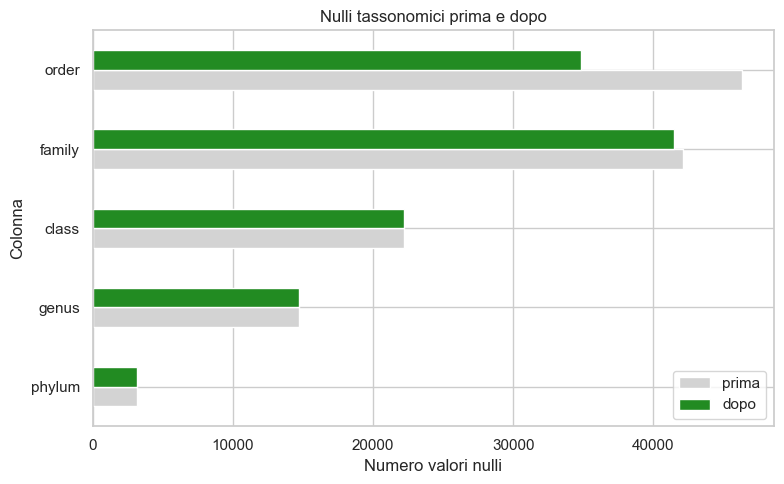

In [102]:
confronto_nulli_tassonomia[['prima', 'dopo']].sort_values('prima').plot(kind='barh', color=['lightgray', verde], figsize=(8, 5))
plt.title('Nulli tassonomici prima e dopo')
plt.xlabel('Numero valori nulli')
plt.ylabel('Colonna')
plt.tight_layout()
plt.show()

#### 7.5.3 Record ancora incompleti

In [103]:
df_fossili_clean[df_fossili_clean[colonne_tassonomia].isnull().any(axis=1)][[
    'accepted_name', 'accepted_rank', 'phylum', 'class', 'order', 'family', 'genus'
]].head(10)

,accepted_name,accepted_rank,phylum,class,order,family,genus
5,Theropoda,unranked clade,Chordata,Reptilia,NaN,NaN,NaN
6,Dinosauria,unranked clade,Chordata,Reptilia,NaN,NaN,NaN
8,Hadrosauridae,family,Chordata,Ornithischia,Ornithischia,Hadrosauridae,NaN
19,Isisaurus colberti,species,Chordata,Saurischia,Saurischia,NaN,Isisaurus
26,Theropoda,unranked clade,Chordata,Reptilia,NaN,NaN,NaN
27,Amygdalodon patagonicus,species,Chordata,Saurischia,Saurischia,NaN,Amygdalodon
31,Titanosauriformes,unranked clade,Chordata,Saurischia,NaN,NaN,NaN
34,Theropoda,unranked clade,Chordata,Reptilia,NaN,NaN,NaN
35,Abelisauridae,family,Chordata,Reptilia,Saurischia,Abelisauridae,NaN
37,Hadrosauridae,family,Chordata,Ornithischia,Ornithischia,Hadrosauridae,NaN


### 7.6 Nota sul metodo

Questo metodo non e' perfetto, pero' e' facile da controllare: prima uso gli ID quando esistono, poi il genere, poi le relazioni gia presenti nel dataset.

I valori riempiti dai CSV di supporto vanno comunque controllati se vengono usati per analisi finali molto precise.

## 8. Conclusioni

### Cose viste

- I due dataset hanno la stessa struttura.
- Il dataset unito si chiama `df_fossili`.
- Il dataset pulito e arricchito si chiama `df_fossili_clean`.
- Ci sono valori mancanti, soprattutto in colonne geografiche e stratigrafiche.
- I duplicati non sembrano essere il problema principale.
- Nel dataset dinosauri conviene togliere `Aves` se si vogliono analizzare solo dinosauri non-aviani.
- Alcuni valori tassonomici tipo `NO_..._SPECIFIED` vanno considerati come nulli.
- Per riempire la tassonomia uso anche alcuni CSV di supporto presenti nella cartella.
- Le feature create possono aiutare nella parte successiva del progetto.

### Prossimi passi

- Decidere quali colonne tenere.
- Gestire i valori mancanti con `dropna()` o `fillna()` in base al caso.
- Usare `df_fossili_clean` per continuare con ETL, data warehouse o dashboard.
- Scegliere i grafici piu utili per il report finale.

# PARTE B - Tema Ecosistema (Giada)

Il dataset di partenza per questa parte e' `df_fossili_clean`, prodotto in Parte A. Rispetto al notebook
originale (`ecosistema_giada.ipynb`), l'unica differenza e' su come si gestiscono gli ordini di uccelli
mesozoici arcaici rimasti classificati come `Reptilia`: invece di **rimuoverli** dal dataset, vengono
**marcati** con un flag booleano (`possibile_aviano_residuo`), gia' presente anche nello star schema condiviso
su Supabase. Questo perche' lo stesso dataset serve anche al tema Evoluzione (Parte D), che ha bisogno proprio
di quelle righe per studiare la transizione verso la linea aviaria.

## B.1 Feature engineering condivise per il tema (flag aviano, continente, ordine raggruppato, categoria)

#### Flag `possibile_aviano_residuo`

Alcuni ordini risultano classificati come `Reptilia`, quindi non erano stati esclusi dal filtro su `class == 'Aves'`
fatto in Parte A. Decisione condivisa nel team: invece di rimuovere queste righe, le marchiamo con un flag
booleano, cosi' il tema ecosistema puo' escluderle dai propri conteggi (sotto, `df_ecosistema`) mentre il tema
evoluzione (Parte D) le puo' usare come segnale di transizione verso la linea aviaria, senza dover mantenere due
dataset puliti diversi.

In [104]:
ordini_aviani_mascherati = [
    'Galliformes',
    'Hesperornithiformes',
    'Ichthyornithes',
    'Alexornithiformes',
    'Colymbiformes',
    'Yanornithiformes',
    'Cathayornithiformes',
    'Eoenantiornithiformes',
    'Jeholornithiformes'
]

df_fossili_clean['possibile_aviano_residuo'] = df_fossili_clean['order'].isin(ordini_aviani_mascherati)

print('Righe marcate come possibile residuo aviano:', df_fossili_clean['possibile_aviano_residuo'].sum())

Righe marcate come possibile residuo aviano: 1137


### Creazione della colonna `continente`

Per analizzare la distribuzione geografica dei fossili e' necessario associare a ogni record il continente di
appartenenza. A partire dai codici paese presenti nel dataset viene creata una nuova colonna (`continente`)
usando la libreria `pycountry_convert`, con una mappatura manuale per i codici non standard o non riconosciuti.

In [105]:
import pycountry_convert as pc

# Codici PBDB non standard o non riconosciuti da pycountry_convert
mappa_continente_manuale = {
    'UK': 'EU',  # Regno Unito
    'AQ': 'AN',  # Antartide
    'TF': 'AN',  # Territori Francesi del Sud (subantartico)
    'TL': 'AS',  # Timor Est
    'PN': 'OC',  # Isole Pitcairn
    'EH': 'AF',  # Sahara Occidentale
}

nomi_continente = {
    'NA': 'Nord America', 'SA': 'Sud America', 'AS': 'Asia',
    'AF': 'Africa', 'OC': 'Oceania', 'EU': 'Europa', 'AN': 'Antartide',
}

def cc_a_continente(cc):
    if pd.isna(cc):
        return np.nan
    if cc in mappa_continente_manuale:
        return nomi_continente[mappa_continente_manuale[cc]]
    try:
        codice = pc.country_alpha2_to_continent_code(cc)
        return nomi_continente.get(codice, 'Sconosciuto')
    except KeyError:
        return 'Sconosciuto'

df_fossili_clean['continente'] = df_fossili_clean['cc'].apply(cc_a_continente)
df_fossili_clean['continente'].value_counts(dropna=False)

continente
Europa          19216
Nord America    18629
Asia            18584
Sud America     11434
Africa           7191
Oceania          2943
Antartide        1654
Sconosciuto       347
NaN                13
Name: count, dtype: int64

### Raggruppamento ordini rari (`order_raggruppato`)

Le piante hanno molti ordini distinti, troppi per una visualizzazione leggibile. Si crea la colonna
`order_raggruppato`, che mantiene i 15 ordini piu' frequenti delle piante e raggruppa il resto in `'Altro'`.
Per i dinosauri la colonna coincide con `order` originale (compresi, per ora, gli ordini aviani mascherati:
verranno esclusi a livello di riga in `df_ecosistema`, non a livello di colonna).

In [106]:
top_ordini_piante = (
    df_fossili_clean[df_fossili_clean['origine_dataset'] == 'piante']['order']
    .value_counts()
    .head(15)
    .index
)

def raggruppa_ordine(row):
    if row['origine_dataset'] == 'dinosauri':
        return row['order']
    if pd.isna(row['order']):
        return np.nan
    if row['order'] in top_ordini_piante:
        return row['order']
    return 'Altro'

df_fossili_clean['order_raggruppato'] = df_fossili_clean.apply(raggruppa_ordine, axis=1)
df_fossili_clean.groupby('origine_dataset')['order_raggruppato'].nunique()

origine_dataset
dinosauri    12
piante       16
Name: order_raggruppato, dtype: int64

### Classificazione trofica (`categoria`)

Per studiare la struttura della rete trofica, i dinosauri vengono classificati in base alla dieta (attraverso la
famiglia tassonomica, con fallback su ordine/classe), e le piante vengono marcate come `'Pianta'`.

In [107]:
famiglie_carnivore = [
    'tyrannosauridae', 'dromaeosauridae', 'troodontidae', 'abelisauridae',
    'spinosauridae', 'megalosauridae', 'carcharodontosauridae', 'caenagnathidae',
    'ornithomimidae', 'compsognathidae', 'noasauridae', 'therizinosauridae'
]

famiglie_erbivore = [
    'hadrosauridae', 'ceratopsidae', 'ankylosauridae', 'nodosauridae',
    'diplodocidae', 'titanosauridae', 'camarasauridae', 'stegosauridae',
    'iguanodontidae', 'massospondylidae', 'brachiosauridae', 'thescelosauridae',
    'pachycephalosauridae', 'psittacosauridae', 'protoceratopsidae'
]

def assegna_macro_categoria(row):
    classe = str(row.get('class', '')).lower()
    ordine = str(row.get('order', '')).lower()
    famiglia = str(row.get('family', '')).lower()
    phylum = str(row.get('phylum', '')).lower()

    if phylum in ['tracheophyta', 'bryophyta', 'pteridophyta'] or 'psilophyta' in phylum or 'coniferophyta' in phylum:
        return 'Pianta'
    elif 'magnoliopsida' in classe or 'liliopsida' in classe or 'pinopsida' in classe:
        return 'Pianta'

    if famiglia in famiglie_carnivore:
        return 'Carnivoro'
    if famiglia in famiglie_erbivore:
        return 'Erbivoro'

    if 'theropoda' in ordine or 'theropoda' in classe:
        return 'Carnivoro'
    elif 'ornithischia' in classe or 'sauropodomorpha' in ordine or 'sauropoda' in ordine:
        return 'Erbivoro'
    elif 'dinosauria' in classe or 'saurischia' in ordine:
        return 'Erbivoro/Incertezza'
    else:
        return 'Altro/Non Classificato'

df_fossili_clean['categoria'] = df_fossili_clean.apply(assegna_macro_categoria, axis=1)
df_fossili_clean['categoria'].value_counts()

categoria
Altro/Non Classificato    46863
Pianta                    19123
Erbivoro                   7887
Carnivoro                  3210
Erbivoro/Incertezza        2928
Name: count, dtype: int64

### Sottoinsieme "ecosistema classico" (`df_ecosistema`)

Da qui in poi le analisi di questa parte lavorano su `df_ecosistema`, cioe' `df_fossili_clean` **senza** le righe
marcate `possibile_aviano_residuo` - coerente con l'obiettivo del tema (l'ecosistema dei dinosauri "classici"),
e con la nota gia' vista in Parte A: "i dinosauri hanno solo 5 ordini" resta vera solo dopo questa esclusione.

In [108]:
df_ecosistema = df_fossili_clean[~df_fossili_clean['possibile_aviano_residuo']].copy()
print('Righe totali:', len(df_fossili_clean), '| righe nel sottoinsieme ecosistema:', len(df_ecosistema))
df_ecosistema.groupby('origine_dataset')['order'].nunique()

Righe totali: 80011 | righe nel sottoinsieme ecosistema: 78874


origine_dataset
dinosauri      3
piante       117
Name: order, dtype: int64

## B.2 Distribuzione ordini tassonomici

In [109]:
ordini_per_dataset = df_ecosistema.groupby('origine_dataset')['order'].value_counts().sort_values(ascending=False)
ordini_per_dataset.groupby(level=0).head(10)

origine_dataset  order          
dinosauri        Saurischia         6807
                 Ornithischia       4630
piante           Coniferales        4011
                 Bennettitales      3149
                 Cycadales          2300
                 Equisetales        1880
                 Ginkgoales         1545
                 Schizaeales        1314
                 Czekanowskiales    1243
                 Cyatheales         1222
                 Dasycladales       1221
                 Gleicheniales      1099
dinosauri        Avetheropoda        167
Name: count, dtype: int64

In [110]:
ordini_distinti = df_ecosistema.groupby('origine_dataset')['order'].nunique()
ordini_distinti

origine_dataset
dinosauri      3
piante       117
Name: order, dtype: int64

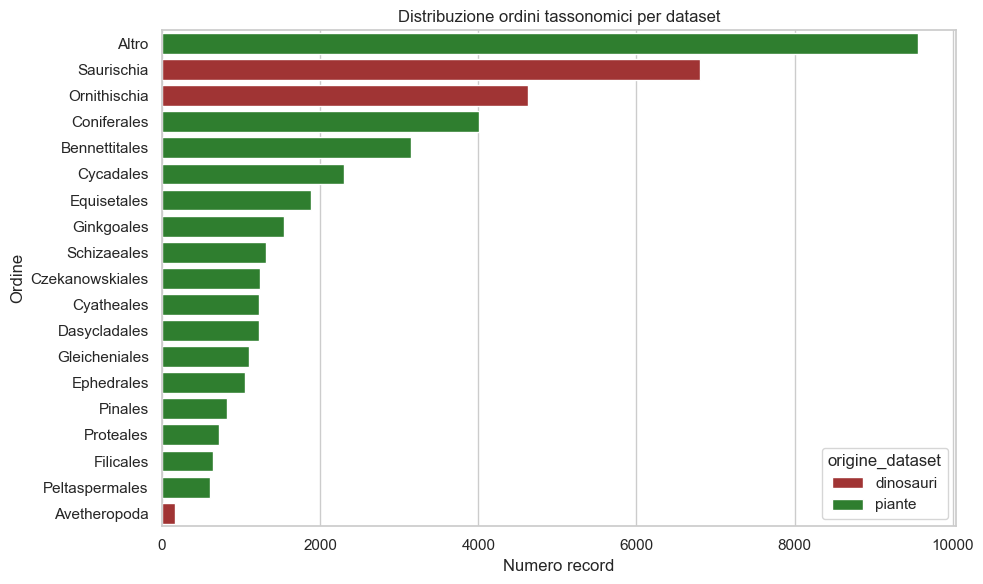

In [111]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_ecosistema,
    y='order_raggruppato',
    hue='origine_dataset',
    order=df_ecosistema['order_raggruppato'].value_counts().index,
    palette=[rosso, verde]
)
plt.title('Distribuzione ordini tassonomici per dataset')
plt.xlabel('Numero record')
plt.ylabel('Ordine')
plt.tight_layout()
plt.show()

## B.3 Distribuzione per era geologica e continente

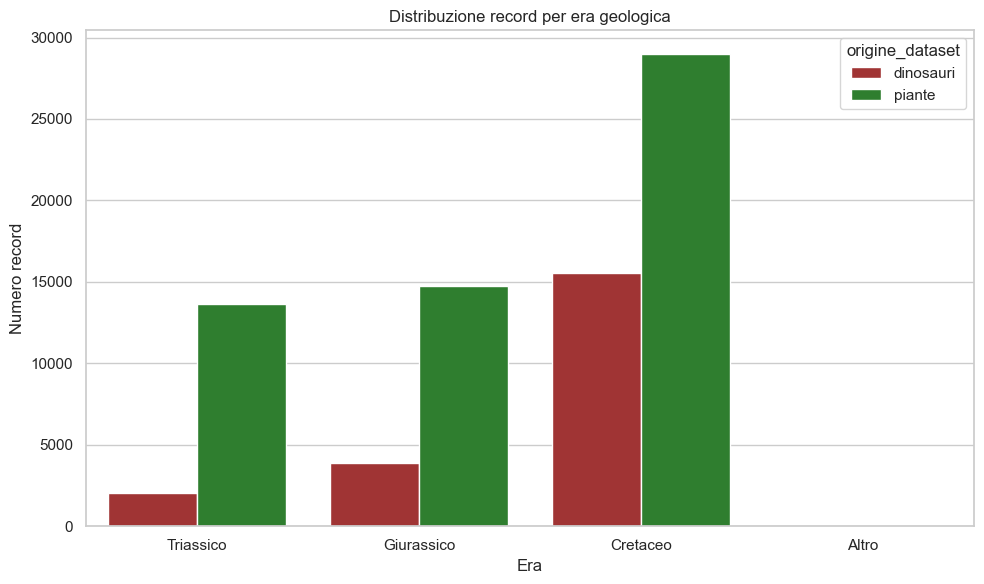

In [112]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_ecosistema,
    x='periodo_mesozoico',
    hue='origine_dataset',
    order=['Triassico', 'Giurassico', 'Cretaceo', 'Altro'],
    palette=[rosso, verde]
)
plt.title('Distribuzione record per era geologica')
plt.xlabel('Era')
plt.ylabel('Numero record')
plt.tight_layout()
plt.show()

In [113]:
ordini_per_era = (
    df_ecosistema
    .groupby(['periodo_mesozoico', 'origine_dataset'])['order_raggruppato']
    .value_counts()
)
ordini_per_era.groupby(level=[0, 1]).head(5)

periodo_mesozoico  origine_dataset  order_raggruppato
Altro              piante           Altro                   4
                                    Peltaspermales          1
Cretaceo           dinosauri        Ornithischia         4154
                                    Saurischia           4115
                                    Avetheropoda          140
                   piante           Altro                6861
                                    Coniferales          1714
                                    Schizaeales          1189
                                    Ephedrales           1009
                                    Proteales             720
Giurassico         dinosauri        Saurischia           1536
                                    Ornithischia          426
                                    Avetheropoda           21
                   piante           Bennettitales        1631
                                    Coniferales          1251
                

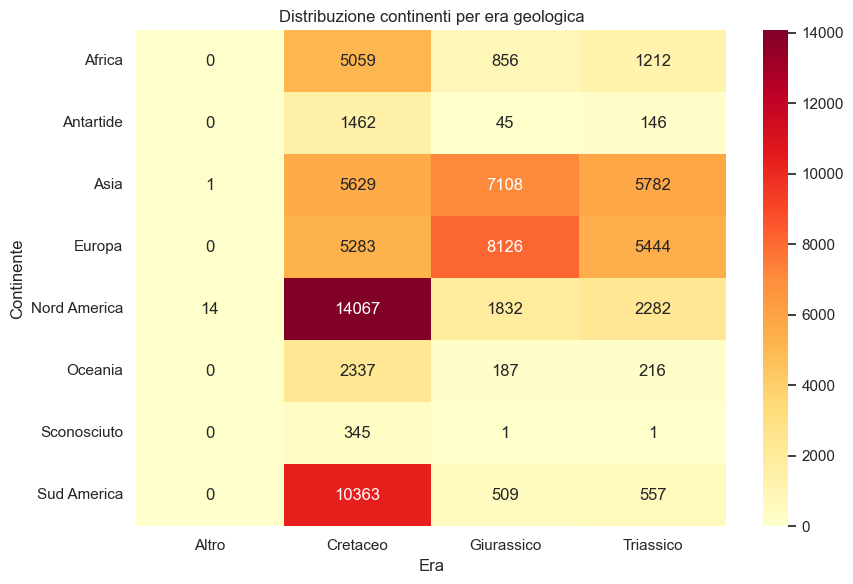

In [114]:
tabella_continente_era = pd.crosstab(df_ecosistema['continente'], df_ecosistema['periodo_mesozoico'])

plt.figure(figsize=(9, 6))
sns.heatmap(tabella_continente_era, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Distribuzione continenti per era geologica')
plt.xlabel('Era')
plt.ylabel('Continente')
plt.tight_layout()
plt.show()

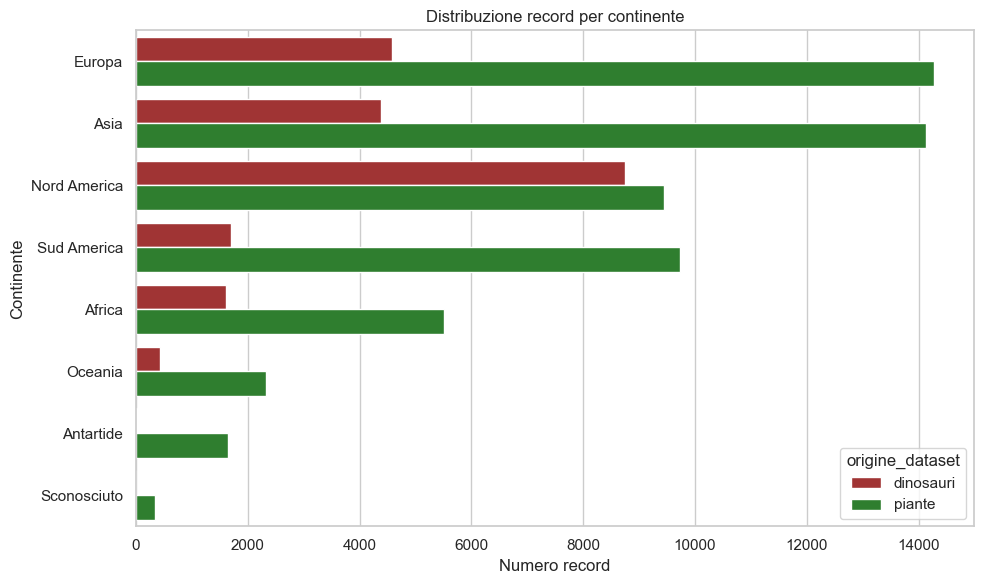

In [115]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_ecosistema,
    y='continente',
    hue='origine_dataset',
    order=df_ecosistema['continente'].value_counts().index,
    palette=[rosso, verde]
)
plt.title('Distribuzione record per continente')
plt.xlabel('Numero record')
plt.ylabel('Continente')
plt.tight_layout()
plt.show()

## B.4 Rete trofica: erbivori, carnivori e piante

In [116]:
conteggio_dieta_era = df_ecosistema[
    df_ecosistema['categoria'].isin(['Erbivoro', 'Carnivoro', 'Erbivoro/Incertezza'])
].groupby(['periodo_mesozoico', 'categoria']).size().unstack(fill_value=0)

conteggio_dieta_era = conteggio_dieta_era.reindex(['Triassico', 'Giurassico', 'Cretaceo'])
conteggio_dieta_era

categoria,Carnivoro,Erbivoro,Erbivoro/Incertezza
periodo_mesozoico,,,
Triassico,9,346,1061
Giurassico,197,1304,826
Cretaceo,3004,6237,1041


In [117]:
percentuale_dieta_era = conteggio_dieta_era[['Erbivoro', 'Carnivoro']]
percentuale_dieta_era = percentuale_dieta_era.div(percentuale_dieta_era.sum(axis=1), axis=0) * 100
percentuale_dieta_era.round(1)

categoria,Erbivoro,Carnivoro
periodo_mesozoico,,
Triassico,97.5,2.5
Giurassico,86.9,13.1
Cretaceo,67.5,32.5


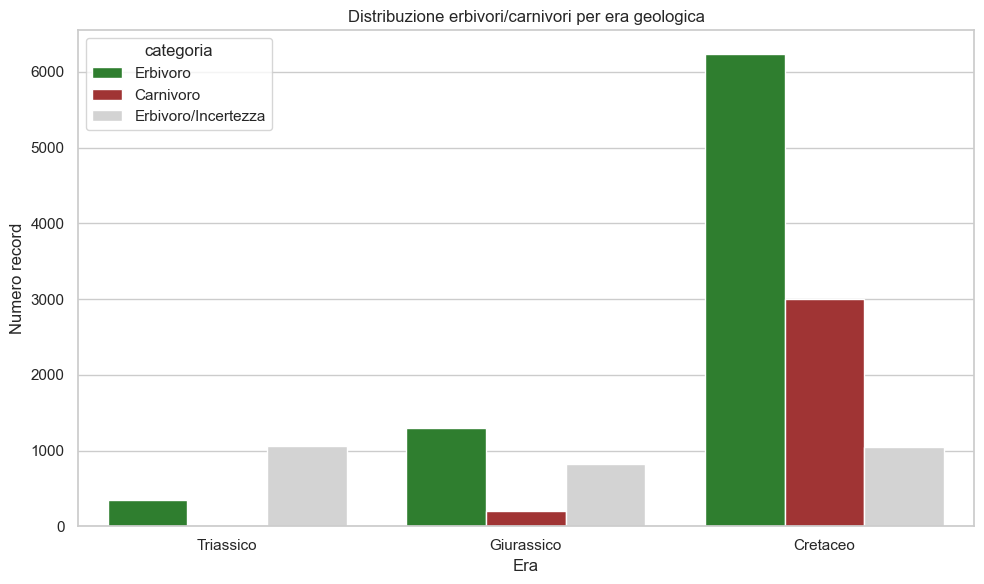

In [118]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_ecosistema[df_ecosistema['categoria'].isin(['Erbivoro', 'Carnivoro', 'Erbivoro/Incertezza'])],
    x='periodo_mesozoico',
    hue='categoria',
    order=['Triassico', 'Giurassico', 'Cretaceo'],
    hue_order=['Erbivoro', 'Carnivoro', 'Erbivoro/Incertezza'],
    palette=[verde, rosso, 'lightgray']
)
plt.title('Distribuzione erbivori/carnivori per era geologica')
plt.xlabel('Era')
plt.ylabel('Numero record')
plt.tight_layout()
plt.show()

### Distribuzione geografica della rete ecologica

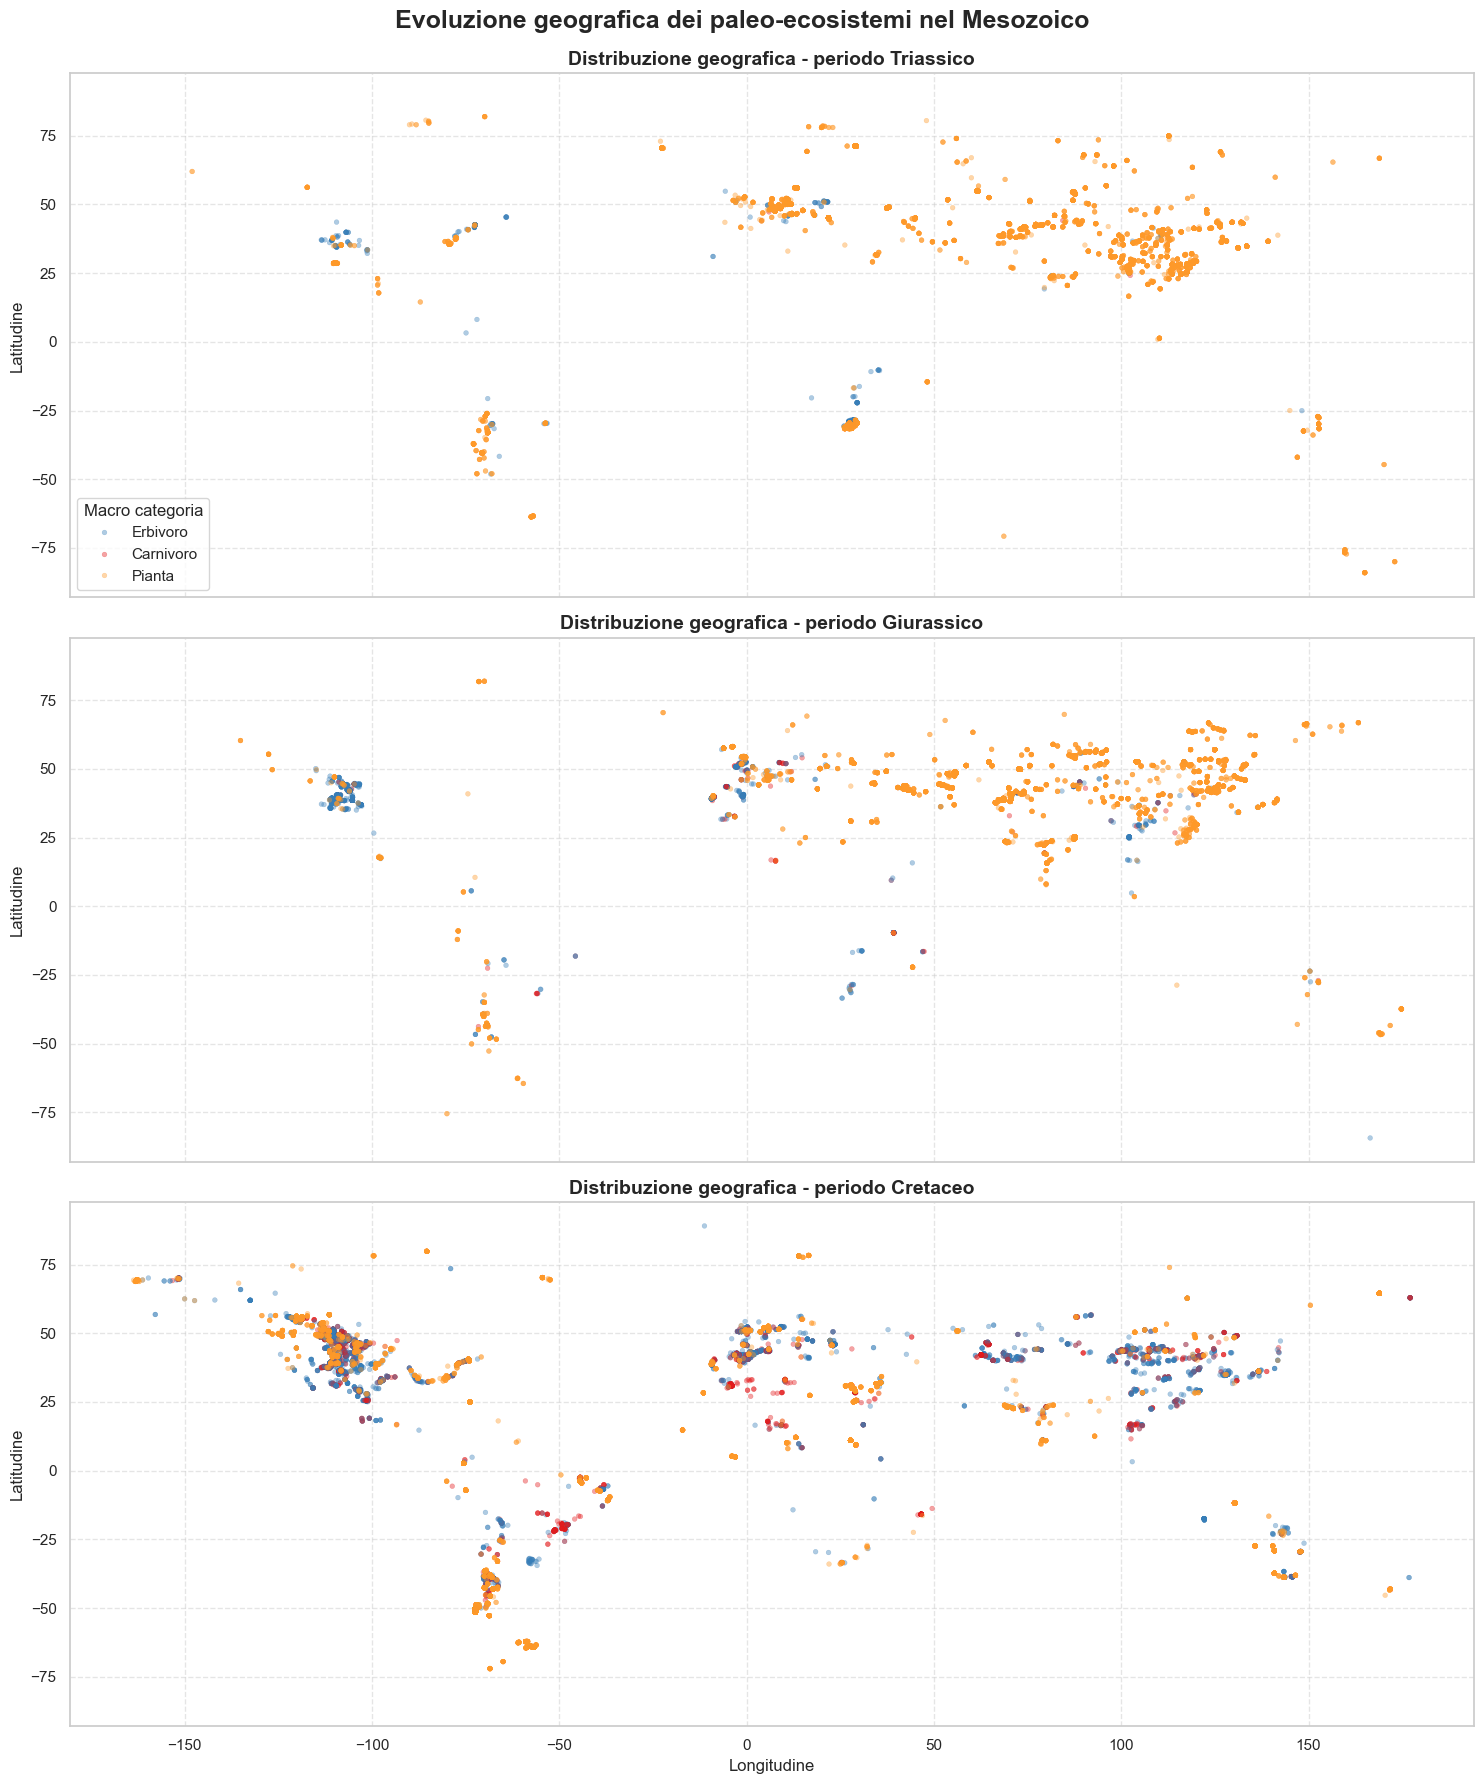

In [119]:
sns.set_theme(style='whitegrid')

df_mappa_ere = df_ecosistema[
    df_ecosistema['periodo_mesozoico'].isin(['Triassico', 'Giurassico', 'Cretaceo']) &
    df_ecosistema['categoria'].isin(['Erbivoro', 'Carnivoro', 'Pianta']) &
    (df_ecosistema['lng'] != 0) & (df_ecosistema['lat'] != 0)
]

palette_contrasto = {
    'Carnivoro': '#e41a1c',
    'Erbivoro': '#377eb8',
    'Pianta': '#fe9929',
}

fig, axes = plt.subplots(3, 1, figsize=(15, 18), sharex=True, sharey=True)
ere = ['Triassico', 'Giurassico', 'Cretaceo']

for i, era in enumerate(ere):
    df_era = df_mappa_ere[df_mappa_ere['periodo_mesozoico'] == era]
    sns.scatterplot(
        data=df_era, x='lng', y='lat', hue='categoria',
        palette=palette_contrasto, alpha=0.4, s=12, edgecolor=None, ax=axes[i]
    )
    axes[i].set_title(f'Distribuzione geografica - periodo {era}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Latitudine')
    axes[i].grid(True, linestyle='--', alpha=0.5)
    if i == 0:
        axes[i].legend(title='Macro categoria', loc='lower left', frameon=True)
    else:
        axes[i].get_legend().remove()

axes[2].set_xlabel('Longitudine')
plt.suptitle('Evoluzione geografica dei paleo-ecosistemi nel Mesozoico', fontsize=18, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()

## B.5 Conclusioni tema Ecosistema

### Cose viste

- La colonna `continente` (ricavata da `cc` con `pycountry_convert`) permette di vedere la distribuzione
  geografica di dinosauri e piante.
- La colonna `order_raggruppato` riassume gli ordini tassonomici. Nel sottoinsieme `df_ecosistema` (dinosauri
  "classici", esclusi i possibili residui aviani) restano solo 3 ordini distinti (`Ornithischia`, `Saurischia`,
  `Avetheropoda`, piu' record senza ordine noto) contro i 117 ordini distinti delle piante, raggruppati nei 15
  piu' frequenti (il resto in `'Altro'`).
- La distribuzione per continente non e' uniforme: alcuni continenti sono molto piu' rappresentati di altri,
  sia per dinosauri che per piante.
- Incrociando continente ed era geologica emergono differenze tra Triassico, Giurassico e Cretaceo: non tutte
  le aree sono documentate in tutti i periodi.
- Il rapporto carnivori/erbivori, calcolato sui fossili classificati, cresce nel tempo. Questo non equivale a un
  vero rapporto di popolazione: i grandi teropodi carnivori sono storicamente piu' studiati e spesso meglio
  conservati rispetto a molti erbivori, quindi il dato risente di un bias di ricerca e di conservazione tipico
  del record fossile.

### Conclusioni finali: vitalita', bias e impatto dell'evento K-Pg

L'analisi dell'ecosistema mesozoico mostra un sistema ricco, dinamico e tutt'altro che semplice. Dinosauri e
piante non sono distribuiti in modo uniforme ne' nello spazio ne' nel tempo: alcuni continenti e alcuni periodi
risultano molto piu' rappresentati di altri, mentre la composizione cambia tra Triassico, Giurassico e Cretaceo.

L'inserimento delle categorie trofiche, anche se basato su una classificazione esplorativa, permette di leggere
meglio il funzionamento dell'ecosistema: le piante rappresentano la base produttiva, gli erbivori il
collegamento diretto con la vegetazione e i carnivori il livello superiore della catena alimentare. Va pero'
sottolineato che l'aumento della quota di carnivori nel tempo non va letto come un vero squilibrio
predatore-preda dell'ecosistema reale: un rapporto cosi' alto sarebbe biologicamente insostenibile in natura.
E' piu' plausibile che rifletta un bias del record fossile, dove i grandi teropodi sono piu' studiati, piu'
spesso ridescritti in letteratura e talvolta meglio conservati rispetto a molti erbivori.

Dal punto di vista ecosistemico, il Mesozoico non appare come un mondo destinato automaticamente al fallimento.
La presenza di piante, erbivori e carnivori indica una rete ecologica funzionante, capace di sostenere relazioni
alimentari e trasformazioni nel tempo. Tuttavia questa rete non era uniforme ne' perfettamente stabile: i dati
mostrano differenze geografiche, cambiamenti tra le ere e una forte concentrazione di alcuni gruppi tassonomici.
Il sistema aveva quindi potenziale evolutivo, ma la scarsita' e i bias dei dati non permettono di affermare con
certezza che sarebbe rimasto sostenibile a lungo termine.

Per questo, il meteorite non puo' essere letto come una "soluzione necessaria", ma come un evento esterno
estremo che ha interrotto bruscamente un ecosistema ancora vitale.

*(Il rapporto carnivori/erbivori misurato su `df_ecosistema` va dal 2.5% nel Triassico, al 13.1% nel Giurassico,
al 32.5% nel Cretaceo - identico a quanto gia' misurato in `ecosistema_giada.ipynb`: usare il flag
`possibile_aviano_residuo` invece del `drop` di riga non cambia questo risultato, cambia solo il conteggio degli
ordini distinti dei dinosauri, vedi sopra.)*

## B.6 Export per la pipeline ETL

Le pipeline (`etl/pipeline.py`, `etl/pipeline_postgres.py`) da qui in poi leggono un unico CSV pulito
(`data/processed/fossili_clean.csv`) invece di `dinos_clean.csv`/`plants_clean.csv`, con le 4 colonne condivise
gia' calcolate sopra (`continente`, `order_raggruppato`, `categoria`, `possibile_aviano_residuo`) gia' pronte,
cosi' le pipeline non devono piu' ricalcolarle in Python.

Le 957 righe con `periodo_mesozoico == 'Altro'` (eta' fuori dal range Mesozoico 66-252 Ma, decisione condivisa
col team) vengono escluse: lo star schema resta cosi' con solo 3 valori per `period_group`.

In [120]:
export_df = df_fossili_clean[df_fossili_clean['periodo_mesozoico'] != 'Altro'].copy()

export_df['dataset_type'] = export_df['origine_dataset'].map({'dinosauri': 'Dinosauria', 'piante': 'Plantae'})

export_df = export_df.rename(columns={
    'eta_media_ma': 'mid_ma',
    'periodo_mesozoico': 'period_group',
    'coordinate_valide': 'has_valid_coords',
})

colonne_export = [
    'occurrence_no', 'collection_no', 'accepted_name', 'accepted_rank',
    'early_interval', 'late_interval', 'max_ma', 'min_ma',
    'lat', 'lng', 'cc', 'state', 'formation', 'geological_group',
    'phylum', 'class', 'order', 'family', 'genus',
    'mid_ma', 'period_group', 'has_valid_coords', 'dataset_type',
    'continente', 'order_raggruppato', 'categoria', 'possibile_aviano_residuo',
]

export_df = export_df[colonne_export]
export_df.to_csv('../data/processed/fossili_clean.csv', index=False)

print('Righe esportate:', len(export_df))
export_df['period_group'].value_counts()

Righe esportate: 79054


period_group
Cretaceo      44740
Giurassico    18664
Triassico     15650
Name: count, dtype: int64

# PARTE C - Tema Decadimento delle specie (Lorenzo)

**Domanda guida:** anche senza il meteorite i dinosauri non aviani si sarebbero estinti in breve, oppure
sarebbero ancora vivi adesso?

Il notebook originale (`EDA_decadimento_specie.ipynb`) caricava un CSV gia' pulito a parte
(`dataset_fossili_pulito.csv`). Qui la stessa logica lavora direttamente su `df_fossili_clean` (Parte A), filtrato
ai soli dinosauri. In piu', usiamo il flag `possibile_aviano_residuo` creato in Parte B per escludere anche gli
ordini di uccelli mesozoici arcaici dal conteggio dei "dinosauri non aviani" - coerente con la domanda del tema,
che riguarda specificamente la linea non aviaria.

## C.1 Preparazione dati

In [121]:
# Colore aggiuntivo usato solo in questa parte per distinguere generi da specie nei grafici
blu_dec = 'steelblue'

In [122]:
dino_c = df_fossili_clean[
    (df_fossili_clean['origine_dataset'] == 'dinosauri')
    & (~df_fossili_clean['possibile_aviano_residuo'])
    & (df_fossili_clean['max_ma'] >= 66)
].copy()

dino_specie_c = dino_c[
    (dino_c['accepted_rank'] == 'species')
    & (dino_c['accepted_name'].notna())
].copy()

riepilogo_c = pd.DataFrame({
    'metrica': [
        'record dinosauri non aviani pre-K-Pg',
        'record a livello specie',
        'specie uniche',
        'generi unici'
    ],
    'valore': [
        len(dino_c),
        len(dino_specie_c),
        dino_specie_c['accepted_name'].nunique(),
        dino_c['genus'].nunique()
    ]
})

riepilogo_c

,metrica,valore
0,record dinosauri non aviani pre-K-Pg,21478
1,record a livello specie,5959
2,specie uniche,2060
3,generi unici,1652


In [123]:
dino_specie_c['eta_media_ma'] = (dino_specie_c['max_ma'] + dino_specie_c['min_ma']) / 2
dino_specie_c['range_temporale_ma'] = dino_specie_c['max_ma'] - dino_specie_c['min_ma']

dino_specie_c[['eta_media_ma', 'range_temporale_ma']].describe()

,eta_media_ma,range_temporale_ma
count,5959.000000,5959.000000
mean,116.817212,9.594707
std,49.894000,6.353308
min,63.830000,0.400000
25%,77.900000,6.200000
50%,97.200000,8.200000
75%,148.950000,11.400000
max,249.301000,167.280000


## C.2 Fasce temporali verso il limite K-Pg

In [124]:
fasce_c = [
    (96, 100.5),
    (91, 96),
    (86, 91),
    (81, 86),
    (76, 81),
    (71, 76),
    (66, 71)
]

righe_c = []
for giovane, antico in fasce_c:
    dati_fascia = dino_c[
        (dino_c['max_ma'] >= giovane)
        & (dino_c['min_ma'] <= antico)
    ]
    dati_fascia_specie = dati_fascia[dati_fascia['accepted_rank'] == 'species']

    righe_c.append({
        'fascia_ma': f'{antico}-{giovane}',
        'specie_uniche': dati_fascia_specie['accepted_name'].nunique(),
        'generi_unici': dati_fascia['genus'].nunique(),
        'record': len(dati_fascia)
    })

tab_decadimento = pd.DataFrame(righe_c)
tab_decadimento

,fascia_ma,specie_uniche,generi_unici,record
0,100.5-96,300,291,2756
1,96-91,247,249,1969
2,91-86,193,187,1151
3,86-81,525,468,5638
4,81-76,430,387,4859
5,76-71,677,579,8911
6,71-66,384,349,4900


In [125]:
range_specie_c = dino_specie_c.groupby('accepted_name').agg({
    'max_ma': 'max',
    'min_ma': 'min',
    'occurrence_no': 'count'
}).reset_index()

range_specie_c = range_specie_c.rename(columns={
    'max_ma': 'prima_comparsa_ma',
    'min_ma': 'ultima_occ_ma',
    'occurrence_no': 'numero_record'
})

range_specie_c.head()

,accepted_name,prima_comparsa_ma,ultima_occ_ma,numero_record
0,Aardonyx celestae,201.4,192.9,1
1,Abdarainurus barsboldi,85.7,72.2,1
2,Abditosaurus kuehnei,72.2,66.0,2
3,Abelichnus astigarrae,100.5,93.9,2
4,Abelisaurus comahuensis,72.2,66.0,1


In [126]:
bins_c = [66, 71, 76, 81, 86, 91, 96, 100.5, 145, 252]
labels_c = ['66-71', '71-76', '76-81', '81-86', '86-91', '91-96', '96-100.5', '100.5-145', '145-252']

range_specie_c['fascia_ultima_occ'] = pd.cut(
    range_specie_c['ultima_occ_ma'],
    bins=bins_c,
    labels=labels_c,
    right=False,
    include_lowest=True
)

ultime_occ_c = range_specie_c['fascia_ultima_occ'].value_counts(sort=False).reset_index()
ultime_occ_c.columns = ['fascia_ultima_occ', 'numero_specie']
ultime_occ_c = ultime_occ_c.iloc[::-1].reset_index(drop=True)

ultime_occ_c

,fascia_ultima_occ,numero_specie
0,145-252,549
1,100.5-145,581
2,96-100.5,0
3,91-96,85
4,86-91,74
5,81-86,93
6,76-81,0
7,71-76,294
8,66-71,383


## C.3 Grafici

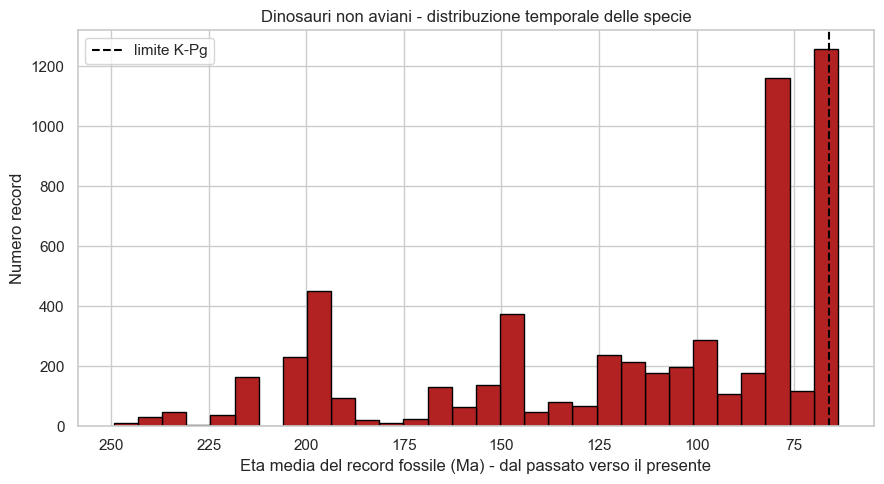

In [127]:
plt.figure(figsize=(9, 5))
plt.hist(dino_specie_c['eta_media_ma'].dropna(), bins=30, color=rosso, edgecolor='black')
plt.axvline(66, color='black', linestyle='--', label='limite K-Pg')
plt.gca().invert_xaxis()
plt.title('Dinosauri non aviani - distribuzione temporale delle specie')
plt.xlabel('Eta media del record fossile (Ma) - dal passato verso il presente')
plt.ylabel('Numero record')
plt.legend()
plt.tight_layout()
plt.show()

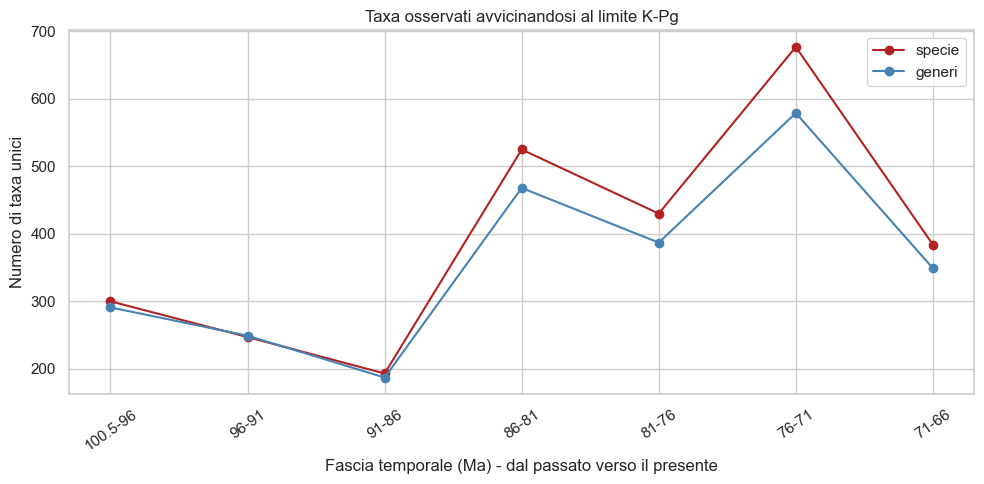

In [128]:
plt.figure(figsize=(10, 5))
plt.plot(tab_decadimento['fascia_ma'], tab_decadimento['specie_uniche'], marker='o', color=rosso, label='specie')
plt.plot(tab_decadimento['fascia_ma'], tab_decadimento['generi_unici'], marker='o', color=blu_dec, label='generi')
plt.title('Taxa osservati avvicinandosi al limite K-Pg')
plt.xlabel('Fascia temporale (Ma) - dal passato verso il presente')
plt.ylabel('Numero di taxa unici')
plt.xticks(rotation=35)
plt.legend()
plt.tight_layout()
plt.show()

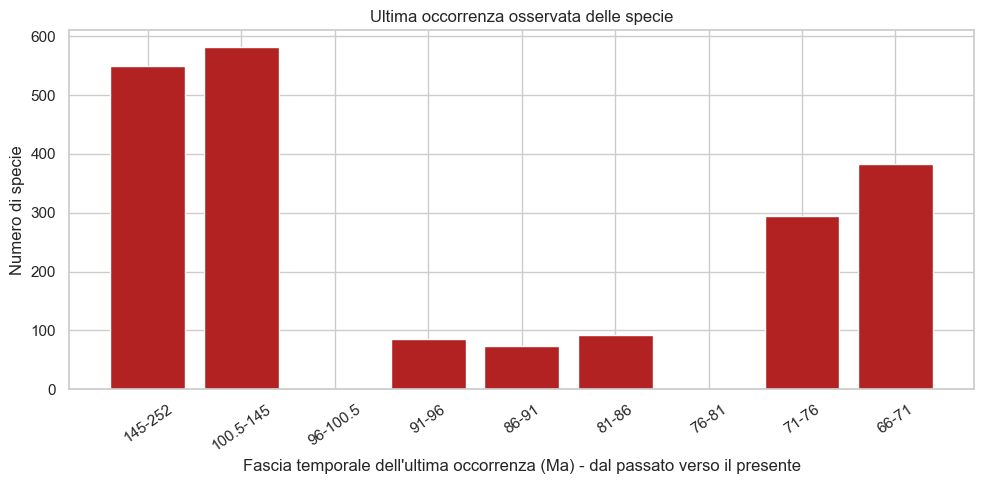

In [129]:
plt.figure(figsize=(10, 5))
plt.bar(ultime_occ_c['fascia_ultima_occ'], ultime_occ_c['numero_specie'], color=rosso)
plt.title('Ultima occorrenza osservata delle specie')
plt.xlabel("Fascia temporale dell'ultima occorrenza (Ma) - dal passato verso il presente")
plt.ylabel('Numero di specie')
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

## C.4 Conclusione tema Decadimento

Dalla tabella delle fasce temporali non si vede un decadimento regolare fino a zero prima del limite K-Pg. Anche
nella fascia piu' vicina al meteorite, 71-66 Ma, sono ancora osservate 384 specie e 349 generi su 4.900 record
(escludendo gia' gli ordini possibilmente aviani via `possibile_aviano_residuo`) - un livello paragonabile, se
non superiore, alle fasce precedenti (es. 91-86 Ma: 193 specie, 187 generi).

Quindi, con questi dati, la risposta piu' prudente e': **non abbiamo evidenza sufficiente per dire che i
dinosauri non aviani si sarebbero estinti in breve anche senza meteorite**.

Pero' non possiamo nemmeno dire che sarebbero ancora vivi oggi. Questa EDA guarda solo il record fossile
disponibile e non simula il futuro, il clima, il vulcanismo, la competizione o altri eventi.

> Nel dataset analizzato i dinosauri non aviani non mostrano un decadimento tale da far prevedere una scomparsa
> naturale imminente prima del limite K-Pg. L'ipotesi di una estinzione a breve termine anche senza meteorite non
> e' quindi supportata da questa EDA, anche se il record fossile non permette di stabilire se sarebbero
> sopravvissuti fino a oggi.

# PARTE D - Tema Evoluzione / linea aviaria (Danilo)

**Domanda guida:** se l'asteroide non fosse caduto, i dinosauri (non-aviani) avevano possibilita' di
sopravvivere? L'evoluzione li stava stabilizzando come specie dominante, oppure li stava gia' trasformando in
qualcosa di troppo diverso dal dinosauro "classico" - cioe' nella linea che porta agli uccelli (Maniraptora /
Paraves / Avialae basali, qui chiamata "linea aviaria")?

Il notebook originale (`evoluzione_Danilo.ipynb`) partiva da `data/processed/dinos_clean.csv`. Qui la stessa
logica lavora su `df_fossili_clean` (Parte A), filtrato ai soli dinosauri. A differenza del tema Decadimento
(Parte C), qui **non** escludiamo le righe con `possibile_aviano_residuo`: quegli ordini (uccelli mesozoici
arcaici rimasti classificati come `Reptilia`) sono proprio il tipo di segnale che serve per studiare la
transizione verso la linea aviaria, insieme alla classificazione `linea_evolutiva` (famiglie/ordini Maniraptora
/ Paraves) definita sotto - una classificazione piu' fine e specifica per questo tema, editoriale e locale a
questo notebook, non condivisa nello star schema.

## D.1 Setup

In [130]:
# Colori dedicati a questa parte: linea classica vs linea aviaria
classico = 'firebrick'
aviario = 'steelblue'

df_evo = df_fossili_clean[df_fossili_clean['origine_dataset'] == 'dinosauri'].copy()
df_evo.shape

(22617, 35)

In [131]:
df_evo[['occurrence_no', 'accepted_name', 'genus', 'family', 'order', 'class',
        'early_interval', 'periodo_mesozoico', 'eta_media_ma']].head()

,occurrence_no,accepted_name,genus,family,order,class,early_interval,periodo_mesozoico,eta_media_ma
2,130209,Chaoyangsaurus youngi,Chaoyangsaurus,Chaoyangsauridae,Ornithischia,Ornithischia,Late Kimmeridgian,Giurassico,142.405
3,130294,Protarchaeopteryx robusta,Protarchaeopteryx,Archaeopterygidae,Saurischia,Reptilia,Late Barremian,Cretaceo,122.670
4,130295,Caudipteryx zoui,Caudipteryx,Caudipterygidae,Saurischia,Reptilia,Late Barremian,Cretaceo,122.670
5,137486,Theropoda,NaN,NaN,NaN,Reptilia,Middle Campanian,Cretaceo,77.900
6,138867,Dinosauria,NaN,NaN,NaN,Reptilia,Berriasian,Cretaceo,128.150


## D.2 Perche' serve una granularita' temporale piu' fine

`periodo_mesozoico` ha solo 3 valori (Triassico, Giurassico, Cretaceo): utile come prima vista, ma troppo grezzo
per guardare cosa succede *appena prima* del confine K-Pg (66 Ma), che cade all'interno del solo Cretaceo.

In [132]:
ordine_periodi_evo = ['Triassico', 'Giurassico', 'Cretaceo']
conteggio_periodi_evo = df_evo['periodo_mesozoico'].value_counts().reindex(ordine_periodi_evo)
conteggio_periodi_evo

periodo_mesozoico
Triassico      2017
Giurassico     3902
Cretaceo      15754
Name: count, dtype: int64

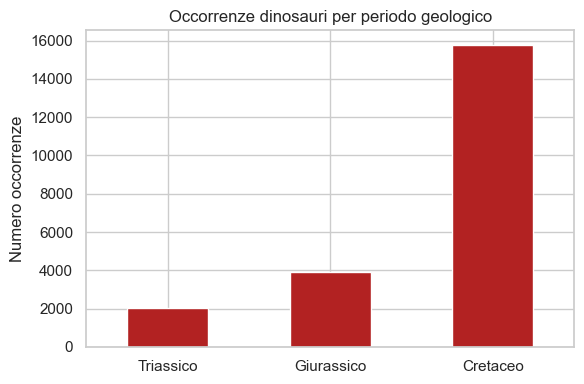

In [133]:
conteggio_periodi_evo.plot(kind='bar', color=classico, figsize=(6, 4))
plt.title('Occorrenze dinosauri per periodo geologico')
plt.ylabel('Numero occorrenze')
plt.xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Dentro il Cretaceo: gli stage di `early_interval`

Stessa cosa ma filtrata sul Cretaceo e ordinata per eta' media (`eta_media_ma`), cosi' vediamo la sequenza
cronologica reale.

In [134]:
cret_evo = df_evo[df_evo['periodo_mesozoico'] == 'Cretaceo'].copy()

eta_media_stage = cret_evo.groupby('early_interval')['eta_media_ma'].mean().sort_values(ascending=False)
conteggio_stage = cret_evo['early_interval'].value_counts().reindex(eta_media_stage.index)
conteggio_stage.head(25)

early_interval
Middle Berriasian     29
Berriasian           397
Late Berriasian      170
Early Berriasian      81
Early Valanginian     30
Late Valanginian      53
Neocomian             36
Valanginian          306
Early Hauterivian      2
Hauterivian           99
Late Hauterivian     169
Early Barremian      250
Late Barremian       458
Early Cretaceous     172
Early Aptian          79
Barremian            330
Late Aptian          230
Aptian               904
Early Albian         243
Gallic                 1
Albian               373
Cretaceous            29
Middle Albian        136
Late Albian          260
Early Cenomanian     465
Name: count, dtype: int64

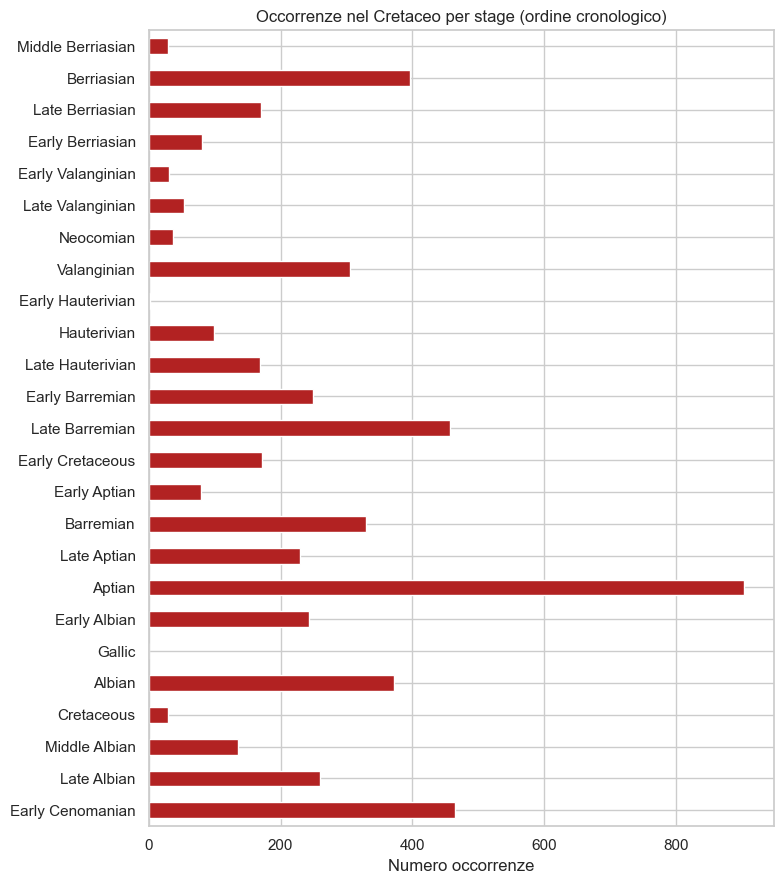

In [135]:
plt.figure(figsize=(8, 9))
conteggio_stage.head(25).iloc[::-1].plot(kind='barh', color=classico)
plt.title('Occorrenze nel Cretaceo per stage (ordine cronologico)')
plt.xlabel('Numero occorrenze')
plt.ylabel('')
plt.tight_layout()
plt.show()

Gli stage sono frammentati in varianti come `Campanian`, `Early Campanian`, `Middle Campanian`,
`Late Campanian`: stesso stage geologico, ma trattato come 4 categorie distinte in `early_interval`. Usare
`early_interval` cosi' com'e' per un confronto quantitativo nel tempo e' fuorviante. Conviene costruire bin
numerici basati su `eta_media_ma`, che e' continua e confrontabile.

## D.3 Feature: bin temporale fine (`stage_bin`)

Bin di ampiezza 5 milioni di anni su `eta_media_ma`, dalla fine del Cretaceo fino all'inizio del Triassico
rappresentato nel dataset.

In [136]:
BIN_WIDTH = 5  # milioni di anni

bordo_massimo = int(np.ceil(df_evo['eta_media_ma'].max() / BIN_WIDTH) * BIN_WIDTH)
bordi_bin = np.arange(0, bordo_massimo + BIN_WIDTH, BIN_WIDTH)

df_evo['stage_bin'] = pd.cut(df_evo['eta_media_ma'], bins=bordi_bin)
df_evo['stage_bin_mid'] = df_evo['stage_bin'].apply(lambda i: i.mid if pd.notnull(i) else np.nan).astype(float)

df_evo[['eta_media_ma', 'stage_bin', 'stage_bin_mid']].head()

,eta_media_ma,stage_bin,stage_bin_mid
2,142.405,"(140, 145]",142.5
3,122.670,"(120, 125]",122.5
4,122.670,"(120, 125]",122.5
5,77.900,"(75, 80]",77.5
6,128.150,"(125, 130]",127.5


### Distribuzione delle occorrenze nel tempo

Istogramma con il confine K-Pg (66 Ma) evidenziato. L'asse e' invertito: il tempo scorre da sinistra (passato
remoto) verso destra (presente).

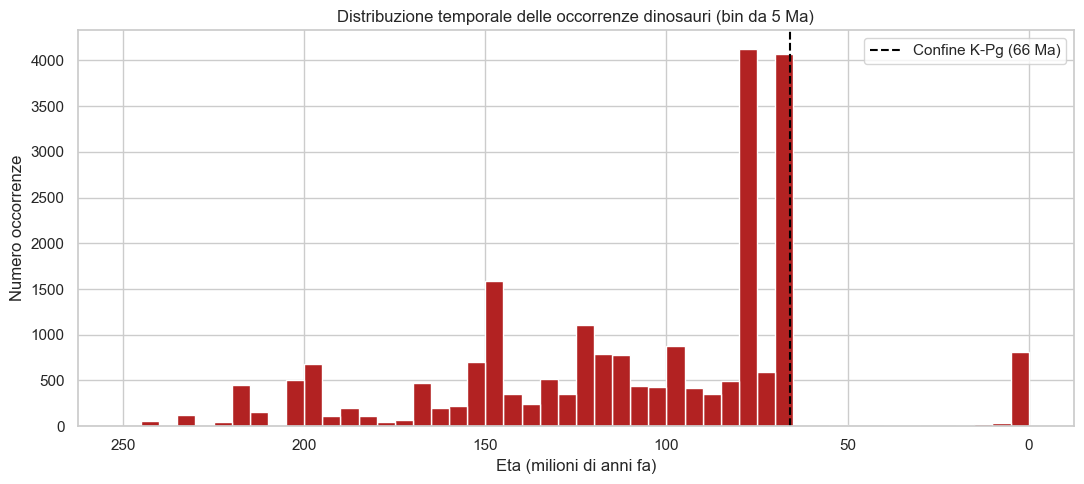

In [137]:
plt.figure(figsize=(11, 5))
plt.hist(df_evo['eta_media_ma'].dropna(), bins=bordi_bin, color=classico, edgecolor='white')
plt.axvline(66, color='black', linestyle='--', label='Confine K-Pg (66 Ma)')
plt.gca().invert_xaxis()
plt.xlabel('Eta (milioni di anni fa)')
plt.ylabel('Numero occorrenze')
plt.title('Distribuzione temporale delle occorrenze dinosauri (bin da 5 Ma)')
plt.legend()
plt.tight_layout()
plt.show()

### Zoom sugli ultimi 20 milioni di anni prima del K-Pg

La finestra che conta davvero per rispondere alla domanda: cosa stava succedendo appena prima dell'impatto?

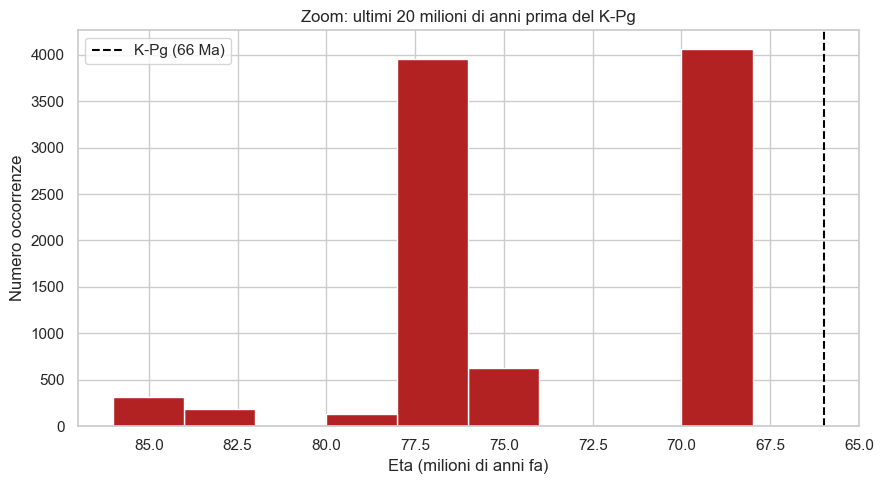

In [138]:
zoom = df_evo[(df_evo['eta_media_ma'] >= 66) & (df_evo['eta_media_ma'] <= 86)]

plt.figure(figsize=(9, 5))
plt.hist(zoom['eta_media_ma'].dropna(), bins=np.arange(66, 88, 2), color=classico, edgecolor='white')
plt.axvline(66, color='black', linestyle='--', label='K-Pg (66 Ma)')
plt.gca().invert_xaxis()
plt.xlabel('Eta (milioni di anni fa)')
plt.ylabel('Numero occorrenze')
plt.title('Zoom: ultimi 20 milioni di anni prima del K-Pg')
plt.legend()
plt.tight_layout()
plt.show()

Alcune occorrenze hanno `eta_media_ma` leggermente inferiore a 66: quasi certamente incertezza di datazione o
fossili rimaneggiati, non sopravvissuti reali alla dominanza non-aviana. Non vengono rimossi, ma vanno tenuti a
mente leggendo i grafici vicino al confine.

In [139]:
(df_evo['eta_media_ma'] < 66).sum(), df_evo.loc[df_evo['eta_media_ma'] < 66, 'eta_media_ma'].min()

(np.int64(947), np.float64(0.00585))

## D.4 Feature: linea evolutiva (classica vs aviaria)

`family`/`order` nel dataset contengono gia' gruppi riconoscibili in letteratura come Maniraptora/Paraves/
Avialae basali - cioe' la linea di teropodi piu' vicina agli uccelli moderni: `Dromaeosauridae`, `Troodontidae`,
`Oviraptoridae`, `Ornithomimidae`, `Ornithomimipodidae` (famiglie) e alcuni ordini di uccelli mesozoici arcaici
non filtrati dall'esclusione di `Aves` fatta in Parte A (`Hesperornithiformes`, `Ichthyornithes`,
`Alexornithiformes`, `Yanornithiformes`, `Cathayornithiformes`, `Eoenantiornithiformes`, `Jeholornithiformes`
- lo stesso elenco di ordini usato per il flag `possibile_aviano_residuo` di Parte B, meno `Galliformes` e
`Colymbiformes`).

**Questa e' una classificazione editoriale**, costruita in base alla letteratura paleontologica, non un campo
nativo del dataset PBDB. Va dichiarata esplicitamente ogni volta che si presentano i risultati. Resta locale a
questo notebook (non viene aggiunta allo star schema condiviso).

In [140]:
famiglie_aviarie = [
    'Dromaeosauridae', 'Troodontidae', 'Oviraptoridae',
    'Ornithomimidae', 'Ornithomimipodidae',
]
ordini_aviari_evo = [
    'Hesperornithiformes', 'Ichthyornithes', 'Alexornithiformes',
    'Yanornithiformes', 'Cathayornithiformes', 'Eoenantiornithiformes',
    'Jeholornithiformes',
]

df_evo['linea_evolutiva'] = np.where(
    df_evo['family'].isin(famiglie_aviarie) | df_evo['order'].isin(ordini_aviari_evo),
    'Linea aviaria', 'Linea classica',
)
df_evo['linea_evolutiva'].value_counts()

linea_evolutiva
Linea classica    20655
Linea aviaria      1962
Name: count, dtype: int64

### Distribuzione per periodo geologico

In [141]:
tabella_periodo_evo = pd.crosstab(df_evo['periodo_mesozoico'], df_evo['linea_evolutiva']).reindex(ordine_periodi_evo)
tabella_periodo_evo

linea_evolutiva,Linea aviaria,Linea classica
periodo_mesozoico,,
Triassico,0,2017
Giurassico,46,3856
Cretaceo,1916,13838


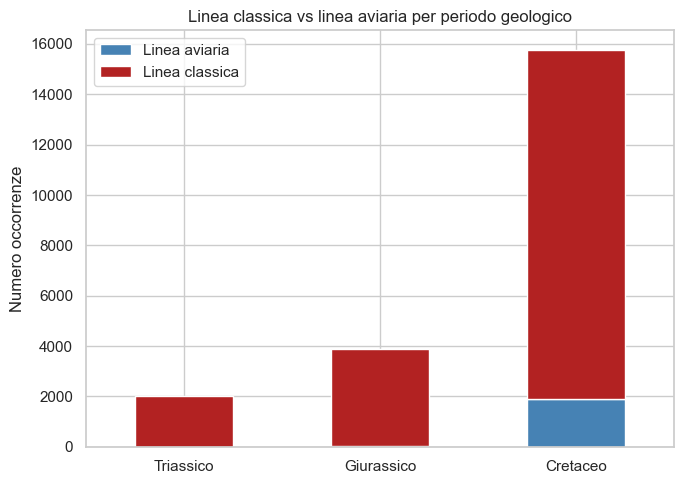

In [142]:
tabella_periodo_evo[['Linea aviaria', 'Linea classica']].plot(
    kind='bar', stacked=True, color=[aviario, classico], figsize=(7, 5)
)
plt.title('Linea classica vs linea aviaria per periodo geologico')
plt.ylabel('Numero occorrenze')
plt.xlabel('')
plt.xticks(rotation=0)
plt.legend(title='')
plt.tight_layout()
plt.show()

## D.5 Gestione dei generi non identificati

In `df_fossili_clean` i valori tassonomici mancanti sono gia' stati convertiti in NaN veri in Parte A (sentinelle
come `NO_GENUS_SPECIFIED` sostituite con `np.nan`), quindi qui basta un controllo di nullita' - a differenza del
notebook originale, che doveva gestire anche il valore sentinella testuale `'Unknown'`.

In [143]:
df_evo['genus_noto'] = df_evo['genus'].notna()

print('Quota genus noto, per riga:', round(df_evo['genus_noto'].mean() * 100, 1), '%')
df_evo.groupby('linea_evolutiva')['genus_noto'].mean().round(3)

Quota genus noto, per riga: 46.6 %


linea_evolutiva
Linea aviaria     0.660
Linea classica    0.448
Name: genus_noto, dtype: float64

## D.6 Ricchezza tassonomica nel tempo

In [144]:
noti = df_evo[df_evo['genus_noto']]

ricchezza = (
    noti.groupby(['stage_bin_mid', 'linea_evolutiva'])['genus']
    .nunique()
    .unstack('linea_evolutiva')
    .fillna(0)
    .sort_index(ascending=False)
)
ricchezza.tail(15)

linea_evolutiva,Linea aviaria,Linea classica
stage_bin_mid,,
77.5,56.0,264.0
72.5,11.0,78.0
67.5,57.0,239.0
62.5,0.0,1.0
52.5,0.0,9.0
47.5,0.0,3.0
42.5,0.0,1.0
37.5,0.0,7.0
32.5,0.0,4.0


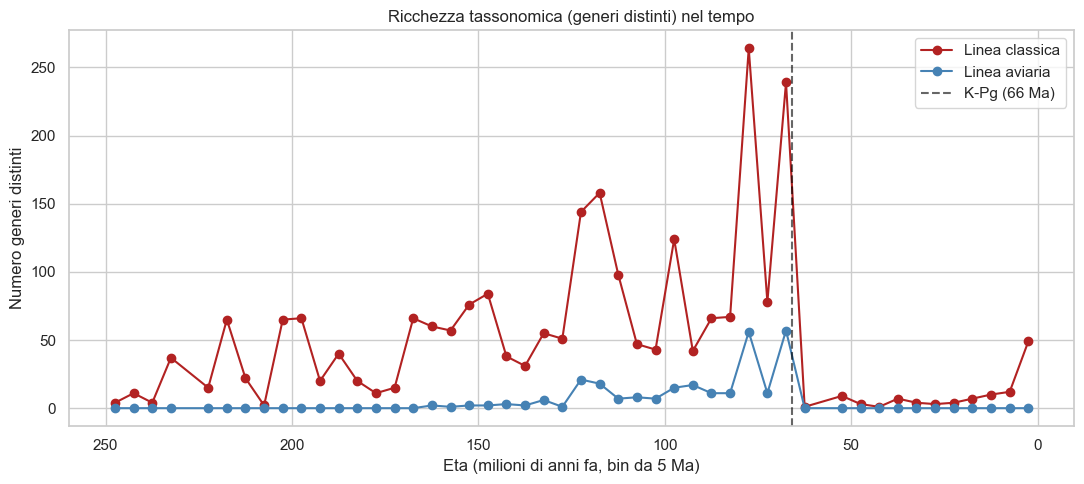

In [145]:
plt.figure(figsize=(11, 5))
plt.plot(ricchezza.index, ricchezza['Linea classica'], color=classico, marker='o', label='Linea classica')
plt.plot(ricchezza.index, ricchezza['Linea aviaria'], color=aviario, marker='o', label='Linea aviaria')
plt.axvline(66, color='black', linestyle='--', alpha=0.6, label='K-Pg (66 Ma)')
plt.gca().invert_xaxis()
plt.xlabel('Eta (milioni di anni fa, bin da 5 Ma)')
plt.ylabel('Numero generi distinti')
plt.title('Ricchezza tassonomica (generi distinti) nel tempo')
plt.legend()
plt.tight_layout()
plt.show()

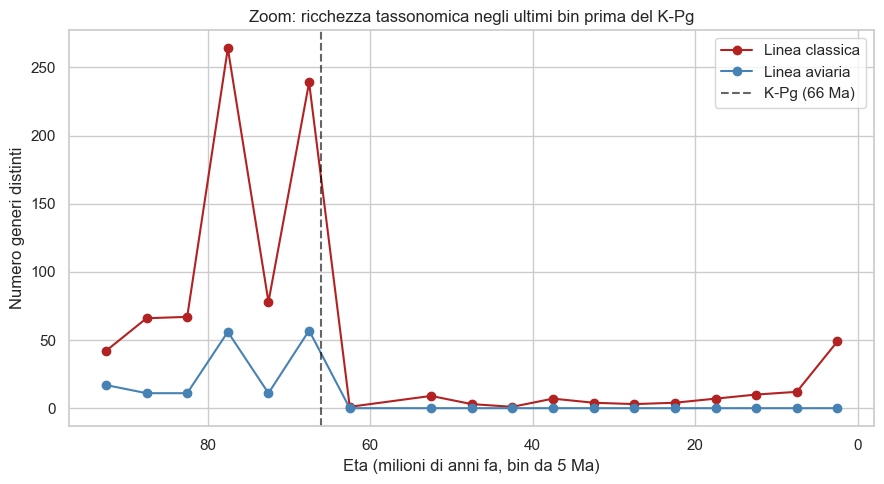

In [146]:
ricchezza_zoom = ricchezza[ricchezza.index <= 96]

plt.figure(figsize=(9, 5))
plt.plot(ricchezza_zoom.index, ricchezza_zoom['Linea classica'], color=classico, marker='o', label='Linea classica')
plt.plot(ricchezza_zoom.index, ricchezza_zoom['Linea aviaria'], color=aviario, marker='o', label='Linea aviaria')
plt.axvline(66, color='black', linestyle='--', alpha=0.6, label='K-Pg (66 Ma)')
plt.gca().invert_xaxis()
plt.xlabel('Eta (milioni di anni fa, bin da 5 Ma)')
plt.ylabel('Numero generi distinti')
plt.title('Zoom: ricchezza tassonomica negli ultimi bin prima del K-Pg')
plt.legend()
plt.tight_layout()
plt.show()

## D.7 Turnover: comparse e ultime occorrenze per bin

Per ogni genere noto, calcolo il `eta_media_ma` piu' alto (comparsa piu' antica) e piu' basso (occorrenza piu'
recente nel dataset).

Attenzione: molti generi in PBDB sono noti da poche occorrenze concentrate in un solo bin: per questi,
"comparsa" e "ultima occorrenza" cadono nello stesso bin. In questi casi il conteggio non rappresenta una vera
dinamica di origination/estinzione biologica, ma solo l'estensione della finestra di ritrovamento nel record
fossile.

In [147]:
prima_ultima = noti.groupby('genus')['eta_media_ma'].agg(
    comparsa_ma='max', ultima_occorrenza_ma='min'
)
linea_per_genere = noti.groupby('genus')['linea_evolutiva'].first()
prima_ultima = prima_ultima.join(linea_per_genere)
prima_ultima.head()

,comparsa_ma,ultima_occorrenza_ma,linea_evolutiva
genus,,,
Aardonyx,197.15,197.15,Linea classica
Abavornis,91.85,91.85,Linea aviaria
Abdarainurus,78.95,78.95,Linea classica
Abditosaurus,69.10,69.10,Linea classica
Abelichnus,97.20,97.20,Linea classica


In [148]:
prima_ultima['bin_comparsa'] = pd.cut(prima_ultima['comparsa_ma'], bins=bordi_bin).apply(
    lambda i: i.mid if pd.notnull(i) else np.nan
).astype(float)
prima_ultima['bin_ultima'] = pd.cut(prima_ultima['ultima_occorrenza_ma'], bins=bordi_bin).apply(
    lambda i: i.mid if pd.notnull(i) else np.nan
).astype(float)

quota_singolo_bin = (prima_ultima['bin_comparsa'] == prima_ultima['bin_ultima']).mean()
print(f'Generi noti da un solo bin temporale: {quota_singolo_bin:.1%}')

Generi noti da un solo bin temporale: 78.8%


In [149]:
origination = prima_ultima.groupby(['bin_comparsa', 'linea_evolutiva']).size().unstack(fill_value=0)
estinzione = prima_ultima.groupby(['bin_ultima', 'linea_evolutiva']).size().unstack(fill_value=0)

origination = origination.sort_index(ascending=False)
estinzione = estinzione.sort_index(ascending=False)
origination.tail(10)

linea_evolutiva,Linea aviaria,Linea classica
bin_comparsa,,
47.5,0,3
42.5,0,1
37.5,0,7
32.5,0,4
27.5,0,2
22.5,0,2
17.5,0,5
12.5,0,3
7.5,0,8


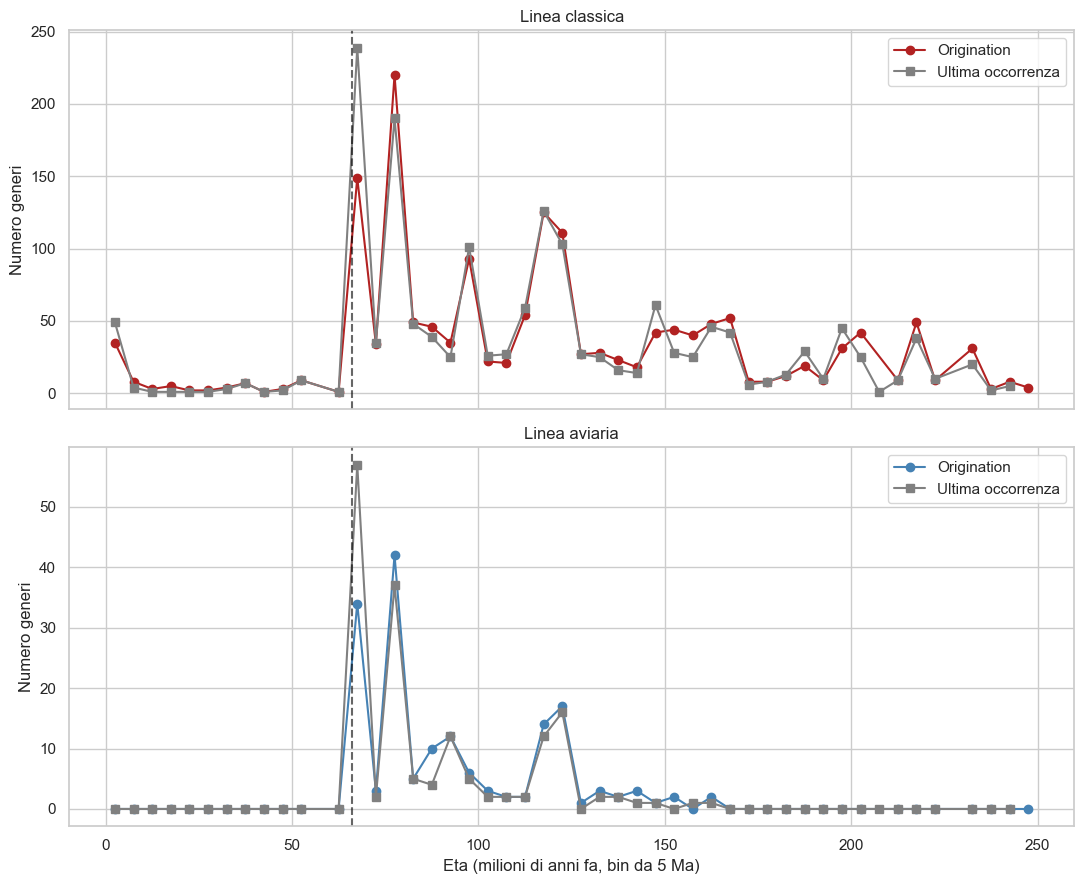

In [150]:
fig, assi = plt.subplots(2, 1, figsize=(11, 9), sharex=True)

assi[0].plot(origination.index, origination['Linea classica'], color=classico, marker='o', label='Origination')
assi[0].plot(estinzione.index, estinzione['Linea classica'], color='gray', marker='s', label='Ultima occorrenza')
assi[0].axvline(66, color='black', linestyle='--', alpha=0.6)
assi[0].set_title('Linea classica')
assi[0].legend()

assi[1].plot(origination.index, origination['Linea aviaria'], color=aviario, marker='o', label='Origination')
assi[1].plot(estinzione.index, estinzione['Linea aviaria'], color='gray', marker='s', label='Ultima occorrenza')
assi[1].axvline(66, color='black', linestyle='--', alpha=0.6)
assi[1].set_title('Linea aviaria')
assi[1].legend()

for ax in assi:
    ax.invert_xaxis()
    ax.set_ylabel('Numero generi')
assi[1].set_xlabel('Eta (milioni di anni fa, bin da 5 Ma)')

plt.tight_layout()
plt.show()

## D.8 Quota della linea aviaria nel tempo

In [151]:
quota_generi_aviaria = (
    ricchezza['Linea aviaria'] / (ricchezza['Linea aviaria'] + ricchezza['Linea classica'])
).replace([np.inf, -np.inf], np.nan) * 100

quota_generi_aviaria.tail(15)

stage_bin_mid
77.5    17.500000
72.5    12.359551
67.5    19.256757
62.5     0.000000
52.5     0.000000
47.5     0.000000
42.5     0.000000
37.5     0.000000
32.5     0.000000
27.5     0.000000
22.5     0.000000
17.5     0.000000
12.5     0.000000
7.5      0.000000
2.5      0.000000
dtype: float64

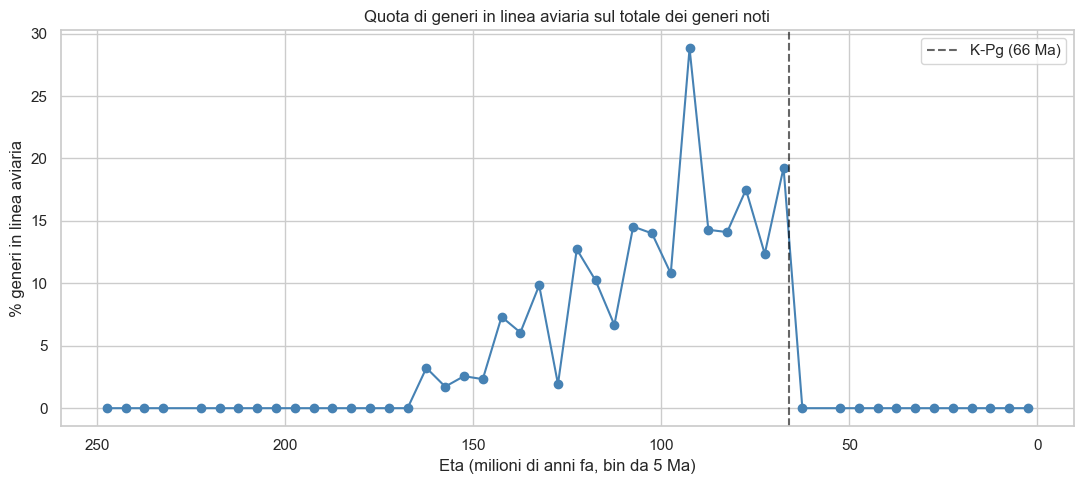

In [152]:
plt.figure(figsize=(11, 5))
plt.plot(quota_generi_aviaria.index, quota_generi_aviaria, color=aviario, marker='o')
plt.axvline(66, color='black', linestyle='--', alpha=0.6, label='K-Pg (66 Ma)')
plt.gca().invert_xaxis()
plt.xlabel('Eta (milioni di anni fa, bin da 5 Ma)')
plt.ylabel('% generi in linea aviaria')
plt.title('Quota di generi in linea aviaria sul totale dei generi noti')
plt.legend()
plt.tight_layout()
plt.show()

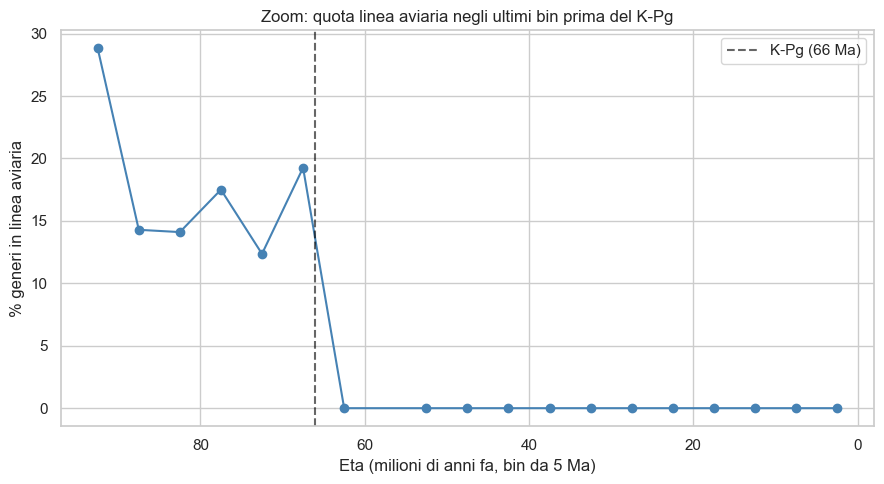

In [153]:
quota_zoom = quota_generi_aviaria[quota_generi_aviaria.index <= 96]

plt.figure(figsize=(9, 5))
plt.plot(quota_zoom.index, quota_zoom, color=aviario, marker='o')
plt.axvline(66, color='black', linestyle='--', alpha=0.6, label='K-Pg (66 Ma)')
plt.gca().invert_xaxis()
plt.xlabel('Eta (milioni di anni fa, bin da 5 Ma)')
plt.ylabel('% generi in linea aviaria')
plt.title('Zoom: quota linea aviaria negli ultimi bin prima del K-Pg')
plt.legend()
plt.tight_layout()
plt.show()

## D.9 Conclusioni tema Evoluzione

*(Questa sezione riprende, con i numeri ricalcolati sull'esecuzione effettiva di questo notebook su
`df_fossili_clean` invece che su `dinos_clean.csv`, le conclusioni gia' validate in `evoluzione_Danilo.ipynb`. I
valori sono leggermente diversi da quel notebook - la pulizia di `EDA_unito` recupera piu' tassonomia grazie
all'arricchimento della sezione 7 - ma la lettura complessiva non cambia.)*

### Cosa mostrano i dati

- **Nessun crollo evidente della ricchezza tassonomica classica appena prima del K-Pg.** Nell'ultimo bin pieno
  prima del confine (67.5 Ma, grosso modo Maastrichtiano) si contano 239 generi noti di "linea classica", un
  livello vicino al massimo storico dell'intera serie (264 nel bin 77.5 Ma, circa Campaniano). A questa
  risoluzione (bin da 5 Ma) non si vede una specie che si sta lentamente spegnendo da sola.
- **Ma quel numero e' probabilmente gonfiato dalla qualita' del campionamento, non solo dalla biologia.** Il
  tardo Maastrichtiano (formazioni come Hell Creek e simili) e' tra gli intervalli piu' studiati in assoluto
  nella paleontologia dei dinosauri: piu' ricerca vuol dire piu' generi trovati, a prescindere da quanto
  l'ecosistema fosse davvero ricco in quel momento.
- **La quota di generi in "linea aviaria" (Maniraptora/Paraves/Avialae basali) sale nel tempo.** Negli ultimi
  ~25 milioni di anni prima del K-Pg oscilla tra il 12.4% e il 28.8% dei generi noti, restando comunque una quota
  rilevante e mai in calo fino alla fine. La parte di "Dinosauria" piu' simile agli uccelli non si stava
  fermando, si stava ritagliando una fetta via via piu' grande della diversita' totale.
- **Le famiglie/ordini della linea aviaria sono identificati al genere molto piu' spesso della linea classica**
  (66.0% contro 44.8% delle occorrenze), probabilmente perche' i siti che li preservano (es. biota cinesi tipo
  Jehol) tendono a conservare scheletri piu' completi - un altro effetto di campionamento da tenere a mente, non
  un segnale biologico.
- **Il turnover (comparsa/ultima occorrenza per bin) va preso con grande cautela**: il 78.8% dei generi noti e'
  documentato in un solo bin da 5 Ma. Per la maggior parte dei generi "origination" ed "estinzione" coincidono
  semplicemente perche' li conosciamo da una manciata di fossili concentrati in una finestra stretta - non e'
  evidenza diretta di vera speciazione o estinzione, ma della finestra con cui il record fossile li ha fatti
  arrivare fino a noi.

### Risposta (cauta) alla domanda guida

I dati a disposizione non mostrano un ecosistema di dinosauri classici gia' in declino nell'ultimo tratto del
Cretaceo: la ricchezza tassonomica resta alta fino alla fine, quindi l'idea di una specie "gia' condannata"
indipendentemente dall'asteroide non trova conferma diretta qui (anche tenendo conto del bias di campionamento a
favore del tardo Maastrichtiano).

Allo stesso tempo, la linea aviaria non e' marginale: rappresenta una quota stabilmente a due cifre della
diversita' nota negli ultimi milioni di anni, senza segni di rallentamento. Questo supporta l'idea che la
"trasformazione verso gli uccelli" fosse un processo evolutivo attivo e in corso in parallelo alla presunta
stabilita' del resto del gruppo - non un'alternativa al declino, ma una terza traiettoria che stava comunque
cambiando la composizione interna di "Dinosauria" indipendentemente da cosa sarebbe successo senza l'impatto.

In sintesi: piu' che "specie dominante e stabile" oppure "specie gia' in declino", il quadro piu' coerente con
questi dati e' **diversita' classica ancora alta ma con una componente aviaria in crescita relativa** -
l'evoluzione non stava necessariamente preparando l'estinzione dei dinosauri classici, ma stava gia' ridefinendo
cosa significasse essere un dinosauro.

### Limiti

- Il dataset PBDB riflette l'intensita' della ricerca paleontologica, non la biodiversita' reale.
- Solo il 46.6% delle occorrenze ha un genere identificato: i conteggi di ricchezza sono un limite inferiore, non
  il totale reale, e la copertura varia per bin e per linea evolutiva (66.0% per la linea aviaria, 44.8% per la
  linea classica).
- La classificazione "linea aviaria" e' una scelta editoriale basata su famiglie/ordini noti in letteratura,
  applicata solo dove famiglia/ordine sono specificati: generi "sconosciuti" a livello di famiglia/ordine che in
  realta' appartengono alla linea aviaria non vengono conteggiati come tali, quindi la quota aviaria stimata e'
  verosimilmente un limite inferiore.
- Bin da 5 Ma e datazioni (`eta_media_ma`) hanno un margine di incertezza stratigrafica non quantificato qui.
- Come per il resto del progetto, queste sono analisi esplorative e descrittive: non permettono conclusioni
  causali forti su "cosa sarebbe successo senza l'asteroide".

# PARTE E - Conclusioni generali

Le tre letture dello stesso dataset (`df_fossili_clean`) raccontano angolazioni diverse della stessa domanda di
fondo - "i dinosauri non aviani erano destinati comunque a scomparire, o l'asteroide ha interrotto qualcosa che
funzionava ancora?":

- **Ecosistema (Parte B)**: la rete trofica (piante, erbivori, carnivori) risulta ricca e attiva fino alla fine
  del Cretaceo, anche se non uniforme nello spazio e nel tempo. Nessun segno di un ecosistema gia' collassato.
- **Decadimento (Parte C)**: guardando solo specie e generi "classici" (non aviani, esclusi anche gli ordini
  possibilmente aviani), non si osserva un declino regolare verso zero nelle fasce temporali immediatamente
  precedenti al K-Pg.
- **Evoluzione (Parte D)**: la diversita' classica resta alta fino alla fine, ma la quota di generi in "linea
  aviaria" cresce nel tempo senza segni di rallentamento - un processo evolutivo attivo, non un'alternativa al
  declino.

Messe insieme, le tre analisi convergono su una lettura comune: **il record fossile disponibile non mostra un
gruppo gia' avviato all'estinzione prima dell'impatto**. Il meteorite va letto come uno shock esterno che ha
interrotto un sistema ancora vitale e in evoluzione (in parte verso la linea aviaria), non come l'atto finale di
un declino gia' in corso. Tutte e tre le letture condividono pero' gli stessi limiti di fondo: il bias di
campionamento del record fossile PBDB, l'incertezza di datazione degli stage geologici, e il fatto che si tratta
di analisi descrittive che non permettono conclusioni causali forti su scenari controfattuali ("cosa sarebbe
successo senza l'asteroide").

## Prossimi passi

- Realineare la pipeline ETL (`etl/pipeline.py`, `etl/pipeline_postgres.py`) a questa pulizia condivisa
  (`df_fossili_clean`) invece che ai CSV prodotti da `cleaning_Danilo.ipynb`, una volta che il team ha validato
  questo notebook.
- Portare le feature specifiche di ogni tema (`linea_evolutiva`, `stage_bin` per il tema Evoluzione;
  eventuali soglie del tema Decadimento) in Power Query/DAX lato Power BI, senza aggiungerle allo star schema
  condiviso - solo le colonne davvero condivise tra piu' temi (`continente`, `order_raggruppato`, `categoria`,
  `possibile_aviano_residuo`) restano nel database.